# Import Libraries

In [1]:
import numpy as np
import pandas as pd 

### Step 1: Data loading

In [ ]:
# Data loading
df = pd.read_csv('../data/ForecastDataset_from_2016_To_2024_for_all_SKUs.csv')

In [3]:
# shape of the DataFrame
df.shape

(1048575, 10)

In [4]:
# Display the first few rows of the DataFrame
df.head()

,ProductFamily,Order_ID,OrderDate,SKU_Description,WareHouseQuantity,SKU,SKU_category,Channel,ShipToState,ShippingZip
0,AIRD,54522457,12/23/2016,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,CA,91403
1,AIRD,54526264,12/28/2016,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,CA,91326
2,AIRD,54536438,12/30/2016,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,DE,19806
3,AIRD,54536647,12/31/2016,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,CA,94903
4,AIRD,54537034,12/31/2016,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,MI,48310


In [5]:
# Display the columns of the DataFrame
df.columns

Index(['ProductFamily', 'Order_ID', 'OrderDate', 'SKU_Description',
       'WareHouseQuantity', 'SKU', 'SKU_category', 'Channel', 'ShipToState',
       'ShippingZip'],
      dtype='object')

In [75]:
df['SKU'].unique()

array(['90AD01AD01', '10AD300GRF01', '10AD300HRF01', '40AD01WC301',
       '10AD02CMPK1', '10AD300PRF03', 'BOGUS SKU', '40AD01WC501',
       '90IL01BJG01', '90AT03AT01', '10AD300GRF01-W', '90AD01AT01-W',
       '10AD01HRF01', '10AD01TF01', 'ATNI', '10AD01GRF01', '10AD01KN095',
       '90ST01ST01', '90AD02AD01', '40AD01TWC301', '40AD02WC301',
       '10AD500PRF02', '10AD500GRF02', '10AD500HRF02', '90AD02AC01',
       '90AD01AC01', '40AD02WC501', '90AD01AD01-HD', '10ST01TS01',
       '10AD500PRF04C', '10AD01PC01', '90AD200AD01', '10AD200GRF01',
       '10AD200PRF03', '10AD200CMPK1', '10AD200HRF01', '40AD200WC301',
       '90AD350AD01', '90AD550AD01', nan, '10AD550HRF02', '30AD500CMPK1',
       '90AT01SCB01', '90AT100AT01', '40AD300MN01', '30AD01B005',
       '30AD01B002', '30AD01B003', '40AD500MN01', '40AD100MN01',
       '10AD01FNF02', '10AD01FNE02', 'Retail-Delivery-Fee', '10AD01FNC02',
       '10AD01FNB02', '10AD01FND02', '10AD01FNA02', '30AD01B008',
       '30AD01B007', '40AD01TWC501

### Step 2: Data Overview / Data Understanding
- `Basic Stats and Structure`

In [6]:
# Display the DataFrame info like data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 10 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   ProductFamily      1048575 non-null  object 
 1   Order_ID           1048575 non-null  int64  
 2   OrderDate          1048575 non-null  object 
 3   SKU_Description    993908 non-null   object 
 4   WareHouseQuantity  1043620 non-null  float64
 5   SKU                1037945 non-null  object 
 6   SKU_category       988952 non-null   object 
 7   Channel            1036144 non-null  object 
 8   ShipToState        1048335 non-null  object 
 9   ShippingZip        1048572 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 80.0+ MB


In [7]:
# Display descriptive statistics of the DataFrame
df.describe(include='all')    # Display descriptive statistics for all columns, including non-numeric ones

,ProductFamily,Order_ID,OrderDate,SKU_Description,WareHouseQuantity,SKU,SKU_category,Channel,ShipToState,ShippingZip
count,1048575,1.048575e+06,1048575,993908,1.043620e+06,1037945,988952,1036144,1048335,1048572
unique,1,NaN,2648,86,NaN,93,9,33,98,50110
top,AIRD,NaN,11/24/2023,Air Doctor AD3000,NaN,90AD01AD01,Filter,WEB_Radial,CA,37064
freq,1048575,NaN,6486,279511,NaN,279511,482734,331986,160353,1093
mean,NaN,4.118648e+07,NaN,NaN,1.176947e+00,NaN,NaN,NaN,NaN,NaN
std,NaN,2.831120e+07,NaN,NaN,5.052335e-01,NaN,NaN,NaN,NaN,NaN
min,NaN,1.554000e+03,NaN,NaN,1.000000e+00,NaN,NaN,NaN,NaN,NaN
25%,NaN,2.207445e+05,NaN,NaN,1.000000e+00,NaN,NaN,NaN,NaN,NaN
50%,NaN,6.004868e+07,NaN,NaN,1.000000e+00,NaN,NaN,NaN,NaN,NaN
75%,NaN,6.147562e+07,NaN,NaN,1.000000e+00,NaN,NaN,NaN,NaN,NaN


In [8]:
# Display the number of unique values in each column
df.nunique()

ProductFamily             1
Order_ID             763423
OrderDate              2648
SKU_Description          86
WareHouseQuantity        24
SKU                      93
SKU_category              9
Channel                  33
ShipToState              98
ShippingZip           50110
dtype: int64

- `Missing Values`

In [9]:
# Check for missing values in the DataFrame which having count more than 0
missing = df.isnull().sum()
print(missing[missing > 0])


SKU_Description      54667
WareHouseQuantity     4955
SKU                  10630
SKU_category         59623
Channel              12431
ShipToState            240
ShippingZip              3
dtype: int64


- `SKU Distribution`

In [10]:
# Total SKUs
total_skus = df['SKU'].nunique()

# SKU distribution per state
sku_per_state = df.groupby('ShipToState')['SKU'].nunique().sort_values(ascending=False)


In [11]:
total_skus

93

In [12]:
sku_per_state

ShipToState
TX            86
CA            84
NY            83
FL            83
NJ            82
              ..
Rincón         1
Washington     1
co             1
guam           1
nv             1
Name: SKU, Length: 98, dtype: int64

- `Outlier Detection (WareHouseQuantity)`
1) Most values of WareHouseQuantity are tightly clustered around 1 to 2 units, as seen by the tall vertical box line.

2) Outliers are clearly visible, going up to 30 units. These could be bulk orders or data anomalies.

Text(0.5, 1.0, 'Outlier Detection for WareHouseQuantity')

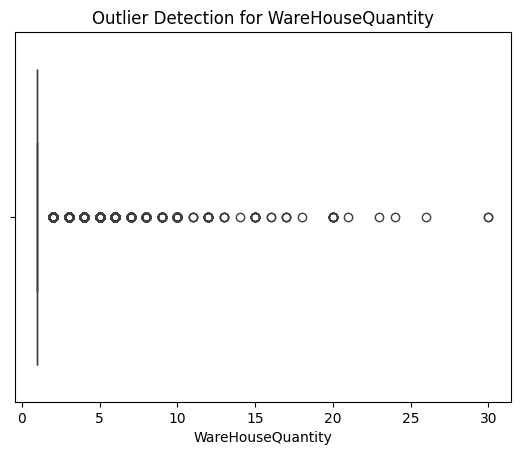

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['WareHouseQuantity'])
plt.title("Outlier Detection for WareHouseQuantity")


### Step 3: Data Cleaning and Anomalies Analysis

**`Checking missing values`**

In [14]:
# Check for missing values in the DataFrame
df.isna().sum()

ProductFamily            0
Order_ID                 0
OrderDate                0
SKU_Description      54667
WareHouseQuantity     4955
SKU                  10630
SKU_category         59623
Channel              12431
ShipToState            240
ShippingZip              3
dtype: int64

In [15]:
# Identify features which having missing values greater than 0 with their count

missing_df = df.isnull().sum().reset_index()
missing_df.columns = ['Features', 'MissingValues']
missing_df = missing_df[missing_df['MissingValues'] > 0]
print(missing_df)


            Features  MissingValues
3    SKU_Description          54667
4  WareHouseQuantity           4955
5                SKU          10630
6       SKU_category          59623
7            Channel          12431
8        ShipToState            240
9        ShippingZip              3


**`Null SKU's Analysis and cleaning`**

Analysis of Missing SKU Data
- Found that **10,630** records have missing SKUs.
- In some records, the **SKU is missing,** but the warehouse quantity is filled — meaning we know how much stock is there, but not which product it belongs to.
- In other records, the **SKU is present,** but the warehouse quantity is missing — we know the product, but not how much Quantity

This shows that the data has some inconsistencies, and we’ll need to clean it based on each case.

In [16]:
# Identify rows where 'SKU' is null
# This will help in understanding which SKUs are missing

missing_skus_df = df[df['SKU'].isnull()]
missing_skus_df


,ProductFamily,Order_ID,OrderDate,SKU_Description,WareHouseQuantity,SKU,SKU_category,Channel,ShipToState,ShippingZip
571965,AIRD,1859,9/27/2022,NaN,1.0,NaN,NaN,paid_social,FL,33486
584239,AIRD,1934,10/19/2022,NaN,1.0,NaN,NaN,organic_social,FL,32724
584257,AIRD,1940,10/19/2022,NaN,1.0,NaN,NaN,organic_social,MN,55429
584300,AIRD,1945,10/19/2022,NaN,1.0,NaN,NaN,organic_social,MN,56264
584447,AIRD,1951,10/19/2022,NaN,1.0,NaN,NaN,organic_social,WA,98006
...,...,...,...,...,...,...,...,...,...,...
1036598,AIRD,271763,4/14/2024,NaN,1.0,NaN,NaN,paid_search,OH,45322
1037380,AIRD,273195,4/15/2024,NaN,1.0,NaN,NaN,Main,NY,10075
1038099,AIRD,273659,4/15/2024,NaN,2.0,NaN,NaN,email,TN,37027
1041141,AIRD,276833,4/20/2024,NaN,1.0,NaN,NaN,Main,CA,94960


In [17]:
# Shape of the DataFrame for missing SKUs
missing_skus_df.shape

(10630, 10)

In [73]:
# Identify rows where 'WareHouseQuantity' is null
# This will help in understanding which WareHouseQuantity are missing

missing_warehouse_quantity_df = df[df['WareHouseQuantity'].isnull()]
missing_warehouse_quantity_df.head(-1)


,ProductFamily,Order_ID,OrderDate,SKU_Description,WareHouseQuantity,SKU,SKU_category,Channel,ShipToState,ShippingZip,Week,Month,Year,DayOfWeek,HighVolumeSale,IsWeekend,Season,CumulativeSales,SKU_RepeatCount
685419,AIRD,41858,2023-01-24,Retail-Delivery-Fee,NaN,Retail-Delivery-Fee,NaN,Main,CO,80124,2023-01-23,1,2023,Tuesday,0,0,Winter,NaN,4955.0
686171,AIRD,41882,2023-01-25,Retail-Delivery-Fee,NaN,Retail-Delivery-Fee,NaN,email,CO,80537,2023-01-23,1,2023,Wednesday,0,0,Winter,NaN,4955.0
685853,AIRD,41953,2023-01-25,Retail-Delivery-Fee,NaN,Retail-Delivery-Fee,NaN,email,CO,80027,2023-01-23,1,2023,Wednesday,0,0,Winter,NaN,4955.0
686012,AIRD,41973,2023-01-25,Retail-Delivery-Fee,NaN,Retail-Delivery-Fee,NaN,email,CO,80303,2023-01-23,1,2023,Wednesday,0,0,Winter,NaN,4955.0
686022,AIRD,41937,2023-01-25,Retail-Delivery-Fee,NaN,Retail-Delivery-Fee,NaN,email,CO,80726,2023-01-23,1,2023,Wednesday,0,0,Winter,NaN,4955.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048564,AIRD,282606,2024-04-29,Retail-Delivery-Fee,NaN,Retail-Delivery-Fee,NaN,email,CO,80634,2024-04-29,4,2024,Monday,0,0,Spring,NaN,4955.0
1048393,AIRD,282216,2024-04-29,Retail-Delivery-Fee,NaN,Retail-Delivery-Fee,NaN,email,CO,81201,2024-04-29,4,2024,Monday,0,0,Spring,NaN,4955.0
1047781,AIRD,282239,2024-04-29,Retail-Delivery-Fee,NaN,Retail-Delivery-Fee,NaN,email,CO,80132,2024-04-29,4,2024,Monday,0,0,Spring,NaN,4955.0
1047980,AIRD,282262,2024-04-29,Retail-Delivery-Fee,NaN,Retail-Delivery-Fee,NaN,Main,CO,80538,2024-04-29,4,2024,Monday,0,0,Spring,NaN,4955.0


**`Yearwise Missing(null) SKU's Count`**

In [18]:
# Step 1: Force datetime conversion on the original DataFrame
df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors='coerce')

# Step 2: Create missing_skus_df *after* conversion to ensure datetime type is preserved
missing_skus_df = df[df['SKU'].isnull() ]

# Step 3: Optional sanity check
print(df['OrderDate'].dtype)               # Should show datetime64[ns]
print(missing_skus_df['OrderDate'].dtype)  # Should also show datetime64[ns]

# Step 4: Now run year-wise count
print("\nYear-wise Distribution in Missing SKU Rows:")
print(missing_skus_df['OrderDate'].dt.year.value_counts().sort_index())


datetime64[ns]
datetime64[ns]

Year-wise Distribution in Missing SKU Rows:
OrderDate
2022    7603
2023    2977
2024      50
Name: count, dtype: int64


**`Missing SKUs Count by Year and Month (with Totals)`**

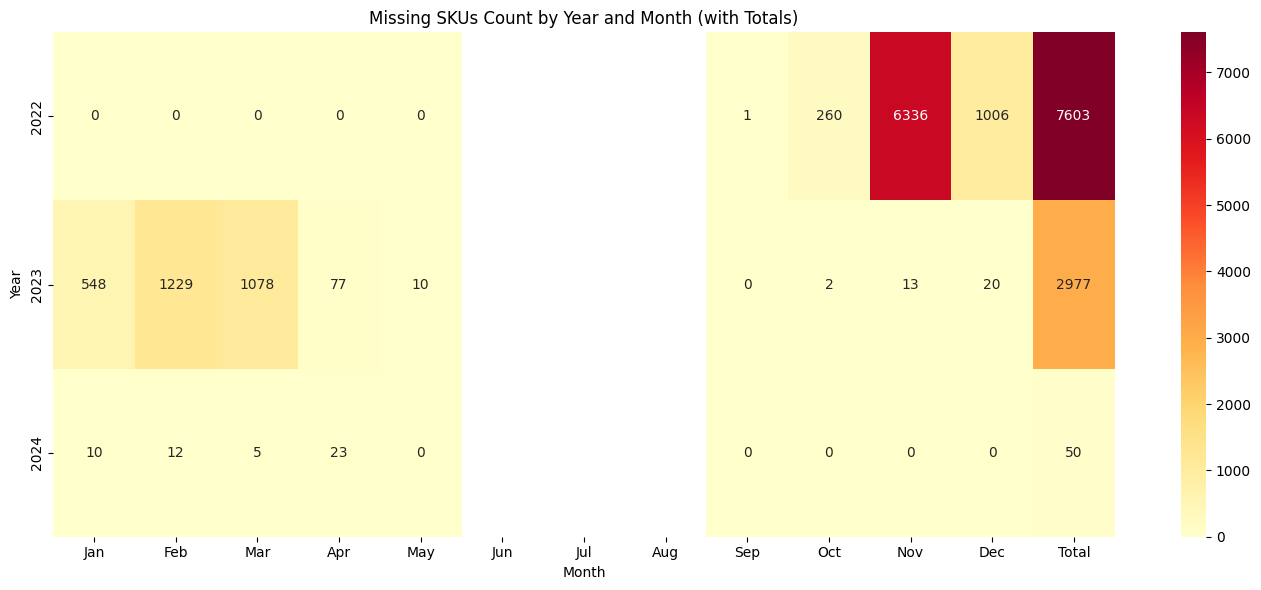

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Ensure OrderDate is datetime
df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors='coerce')

# Step 2: Filter rows where SKU is missing
missing_skus_df = df[df['SKU'].isnull()].copy()

# Step 3: Extract Year and Month
missing_skus_df['Year'] = missing_skus_df['OrderDate'].dt.year
missing_skus_df['Month'] = missing_skus_df['OrderDate'].dt.month_name().str[:3]

# Step 4: Create pivot table with month columns
heatmap_data = missing_skus_df.pivot_table(index='Year', columns='Month', aggfunc='size', fill_value=0)

# Step 5: Reorder months
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
heatmap_data = heatmap_data.reindex(columns=month_order)

# Step 6: Add year-wise total column
heatmap_data['Total'] = heatmap_data.sum(axis=1)

# Step 7: Plot heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Missing SKUs Count by Year and Month (with Totals)')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.show()


**`Missing WareHouseQuantity Count by Year and Month (with Totals)`**

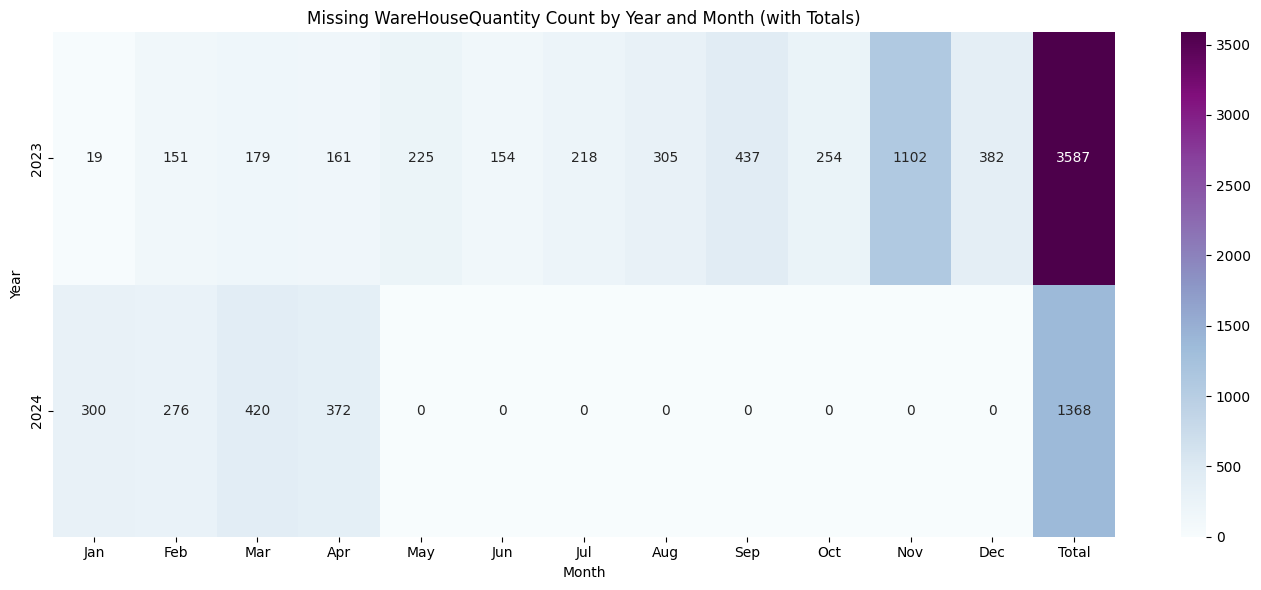

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Ensure 'OrderDate' is in datetime format
df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors='coerce')

# Step 2: Filter rows where 'WareHouseQuantity' is missing
missing_qty_df = df[df['WareHouseQuantity'].isnull()].copy()

# Step 3: Extract Year and Month
missing_qty_df['Year'] = missing_qty_df['OrderDate'].dt.year
missing_qty_df['Month'] = missing_qty_df['OrderDate'].dt.month_name().str[:3]  # e.g., Jan, Feb

# Step 4: Create pivot table (count of missing per Year-Month)
heatmap_qty = missing_qty_df.pivot_table(index='Year', columns='Month', aggfunc='size', fill_value=0)

# Step 5: Reorder months for better readability
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
heatmap_qty = heatmap_qty.reindex(columns=month_order)

# Step 6: Add total column per year
heatmap_qty['Total'] = heatmap_qty.sum(axis=1)

# Step 7: Plot heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_qty, annot=True, fmt='.0f', cmap='BuPu')
plt.title('Missing WareHouseQuantity Count by Year and Month (with Totals)')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.show()


**`Case 1: Filter rows where SKU is null but WareHouseQuantity is present`**

In [21]:
# Filter rows where SKU is null but WareHouseQuantity is present
# This will help in understanding which SKUs are missing but have some quantity recorded

sku_null_qty_present = missing_skus_df[
    missing_skus_df['SKU'].isnull() & missing_skus_df['WareHouseQuantity'].notnull()
]

print("SKU is null but WareHouseQuantity is present:")
print(sku_null_qty_present[['OrderDate', 'SKU', 'WareHouseQuantity']].head(20))


SKU is null but WareHouseQuantity is present:
        OrderDate  SKU  WareHouseQuantity
571965 2022-09-27  NaN                1.0
584239 2022-10-19  NaN                1.0
584257 2022-10-19  NaN                1.0
584300 2022-10-19  NaN                1.0
584447 2022-10-19  NaN                1.0
584576 2022-10-19  NaN                1.0
584616 2022-10-19  NaN                1.0
584870 2022-10-20  NaN                1.0
584892 2022-10-20  NaN                1.0
585530 2022-10-21  NaN                1.0
585532 2022-10-21  NaN                1.0
586353 2022-10-22  NaN                1.0
586448 2022-10-22  NaN                1.0
586754 2022-10-23  NaN                1.0
587297 2022-10-24  NaN                1.0
587964 2022-10-26  NaN                1.0
587972 2022-10-26  NaN                1.0
588058 2022-10-26  NaN                1.0
588064 2022-10-26  NaN                4.0
588300 2022-10-26  NaN                1.0


**`Case 2: Filter rows where SKU is present but WareHouseQuantity is null`**

In [22]:
# Filter rows where SKU is present but WareHouseQuantity is null
# This will help in understanding which SKUs are present but have no quantity recorded

sku_present_qty_null = missing_skus_df[
    missing_skus_df['SKU'].notnull() & missing_skus_df['WareHouseQuantity'].isnull()
]

print("\nSKU is present but WareHouseQuantity is null:")
print(sku_present_qty_null[['OrderDate', 'SKU', 'WareHouseQuantity']].head(20))



SKU is present but WareHouseQuantity is null:
Empty DataFrame
Columns: [OrderDate, SKU, WareHouseQuantity]
Index: []


#### Visualization of Missing SKU's and WareHouseQuantity Cases

In [23]:
# Case 1: SKU is null, WareHouseQuantity is not null
sku_null_qty_present = missing_skus_df[
    missing_skus_df['SKU'].isnull() & missing_skus_df['WareHouseQuantity'].notnull()
].copy()
sku_null_qty_present['IssueType'] = 'SKU Missing'

# Case 2: SKU is present, WareHouseQuantity is null
sku_present_qty_null = missing_skus_df[
    missing_skus_df['SKU'].notnull() & missing_skus_df['WareHouseQuantity'].isnull()
].copy()
sku_present_qty_null['IssueType'] = 'Quantity Missing'

# Combine both into one DataFrame
issue_df = pd.concat([sku_null_qty_present, sku_present_qty_null])

# Ensure datetime format and extract month-year
issue_df['Month'] = issue_df['OrderDate'].dt.to_period('M').astype(str)


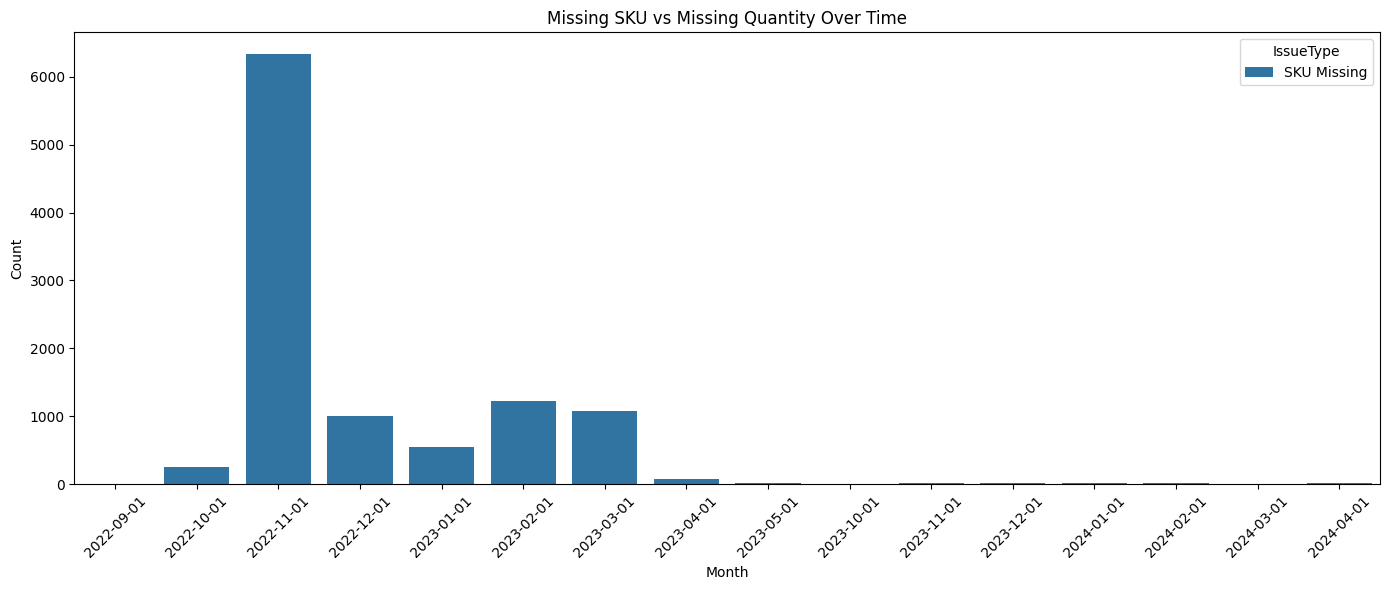

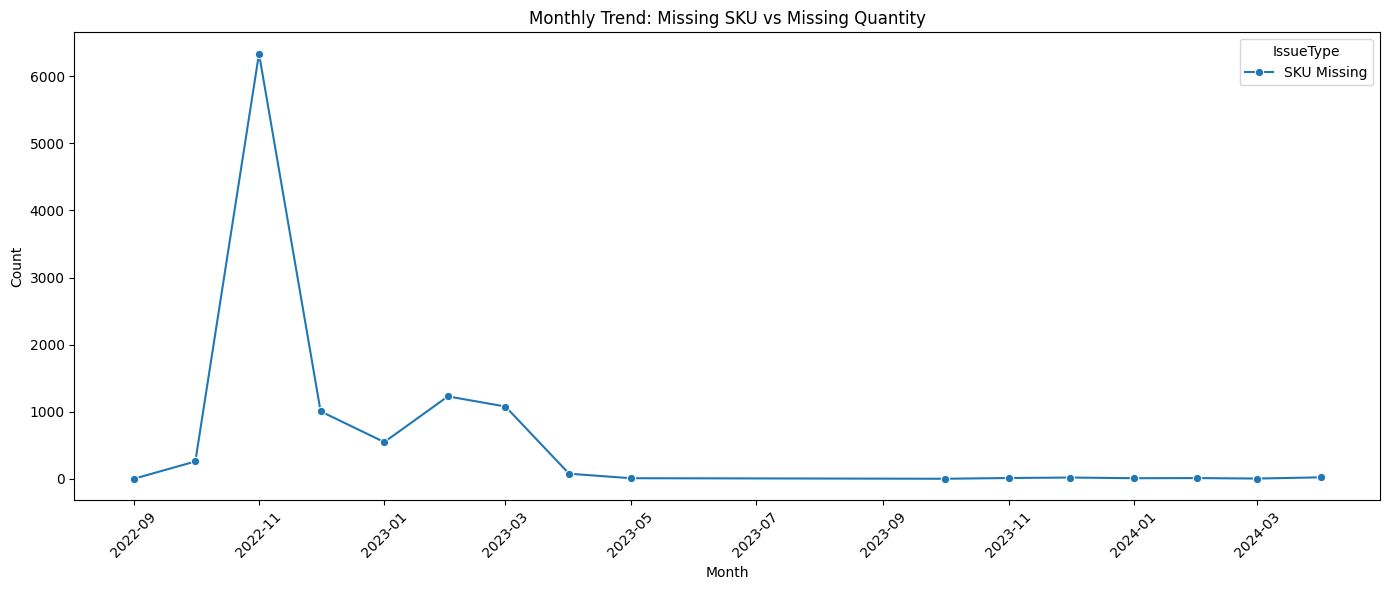

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure Month is in datetime format and sort
issue_df['Month'] = pd.to_datetime(issue_df['Month'])
issue_counts = issue_df.groupby(['Month', 'IssueType']).size().reset_index(name='Count')
issue_counts = issue_counts.sort_values('Month')

# Bar plot
plt.figure(figsize=(14, 6))
sns.barplot(data=issue_counts, x='Month', y='Count', hue='IssueType')
plt.xticks(rotation=45)
plt.title('Missing SKU vs Missing Quantity Over Time')
plt.xlabel('Month')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Line plot
plt.figure(figsize=(14, 6))
sns.lineplot(data=issue_counts, x='Month', y='Count', hue='IssueType', marker='o')
plt.xticks(rotation=45)
plt.title('Monthly Trend: Missing SKU vs Missing Quantity')
plt.xlabel('Month')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


#### Total Missing SKU and WareHouseQuantity Count Analysis
- Case 1: Both SKU and WareHouseQuantity are missing
- Case 2: SKU is missing, but WareHouseQuantity is present
- Case 3: WareHouseQuantity is missing, but SKU is present

In [25]:
# Case 1: Both SKU and WareHouseQuantity are missing
both_missing = df[df['SKU'].isnull() & df['WareHouseQuantity'].isnull()]

# Case 2: SKU is missing, but WareHouseQuantity is present
sku_missing = df[df['SKU'].isnull() & df['WareHouseQuantity'].notnull()]

# Case 3: WareHouseQuantity is missing, but SKU is present
warehouse_missing = df[df['SKU'].notnull() & df['WareHouseQuantity'].isnull()]


In [26]:
# Store the counts in a dictionary
missing_counts = {
    'Both SKU & WareHouseQuantity Missing': len(both_missing),
    'Only SKU Missing': len(sku_missing),
    'Only WareHouseQuantity Missing': len(warehouse_missing)
}


**`Visualization`**

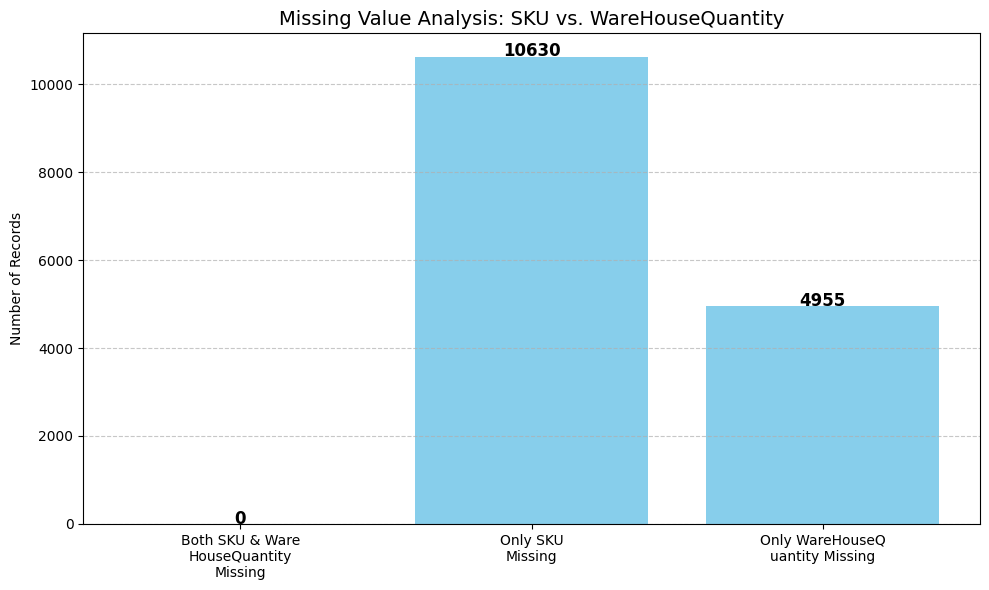

In [27]:
import textwrap

# Wrap x-axis labels to break into multiple lines
wrapped_labels = [
    "\n".join(textwrap.wrap(label, width=15)) for label in missing_counts.keys()
]

# Re-plot with wrapped labels
plt.figure(figsize=(10, 6))
plt.bar(wrapped_labels, missing_counts.values(), color='skyblue')

for i, value in enumerate(missing_counts.values()):
    plt.text(i, value + 5, str(value), ha='center', fontsize=12, fontweight='bold')

plt.title('Missing Value Analysis: SKU vs. WareHouseQuantity', fontsize=14)
plt.ylabel('Number of Records')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Step 3: Univariate Analysis

**`1. Univariate Analysis`**
    
**Definition:** Analysis involving only one variable.

**Purpose:** Understand the distribution, central tendency, and spread of a single variable.

**Examples:**

- Analyzing the distribution of SKU counts.
- Plotting a histogram of WareHouseQuantity.
- Calculating mean, median, mode of WareHouseQuantity.

**`Common Charts:`**
    - Histogram , Box plot, Pie chart, Bar chart


**`Distribution of WareHouseQuantity`**

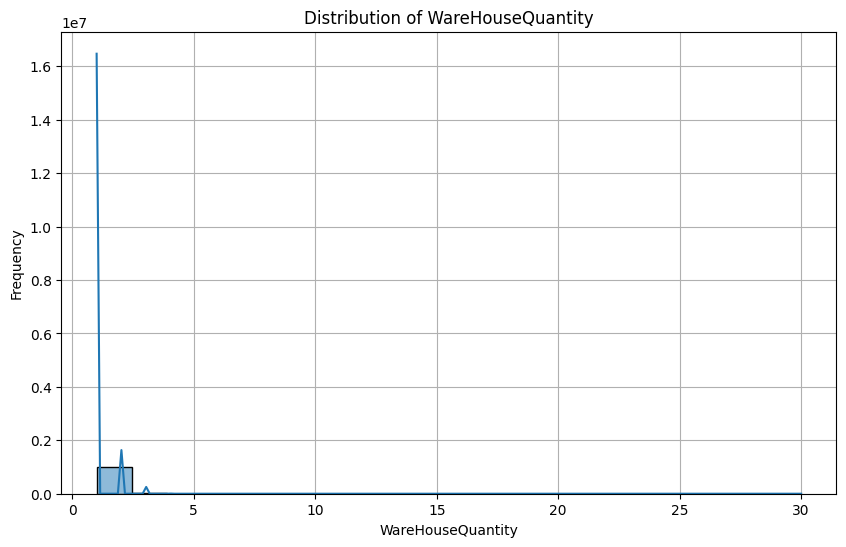

In [28]:
# Convert OrderDate to datetime just in case
df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors='coerce')

# Plotting Histogram and KDE (Distribution Plot)
plt.figure(figsize=(10, 6))
sns.histplot(df['WareHouseQuantity'], bins=20, kde=True)
plt.title("Distribution of WareHouseQuantity")
plt.xlabel("WareHouseQuantity")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

**`Analysis of 'WareHouseQuantity' column`**

In [29]:
# Analysis of 'WareHouseQuantity' column
# Check if 'WareHouseQuantity' column exists
if 'WareHouseQuantity' in df.columns:
    mean_val = df['WareHouseQuantity'].mean()
    median_val = df['WareHouseQuantity'].median()
    mode_val = df['WareHouseQuantity'].mode()

    print(f"Mean WareHouseQuantity: {mean_val}")
    print(f"Median WareHouseQuantity: {median_val}")
    print(f"Mode WareHouseQuantity: {mode_val.tolist()}")  # mode can return multiple values
    print(f"Max WareHouseQuantity: {df["WareHouseQuantity"].max()}")
    print(f"Min WareHouseQuantity: {df["WareHouseQuantity"].min()}")
else:
    print("The column 'WareHouseQuantity' is not present in the dataset.")


Mean WareHouseQuantity: 1.1769465897548916
Median WareHouseQuantity: 1.0
Mode WareHouseQuantity: [1.0]
Max WareHouseQuantity: 30.0
Min WareHouseQuantity: 1.0


**`Univariate Analysis of remaining features`**

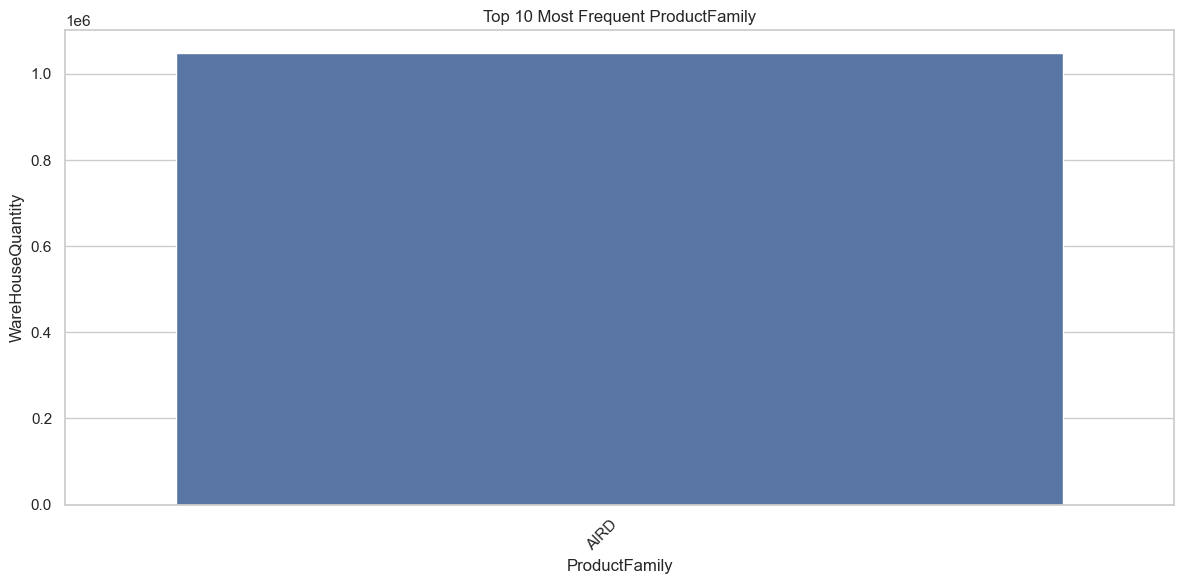

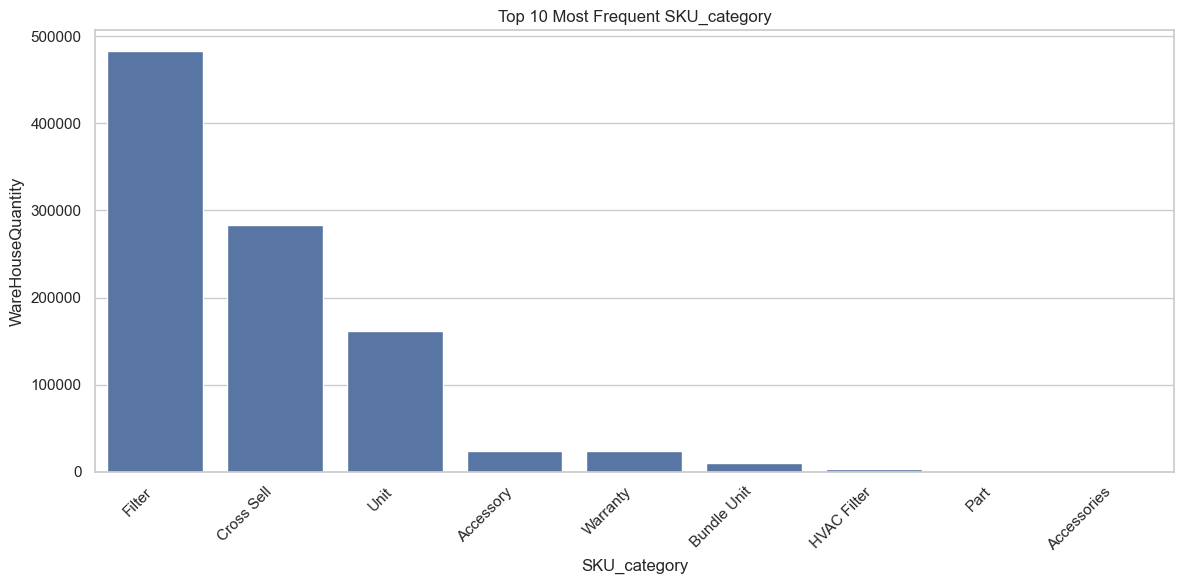

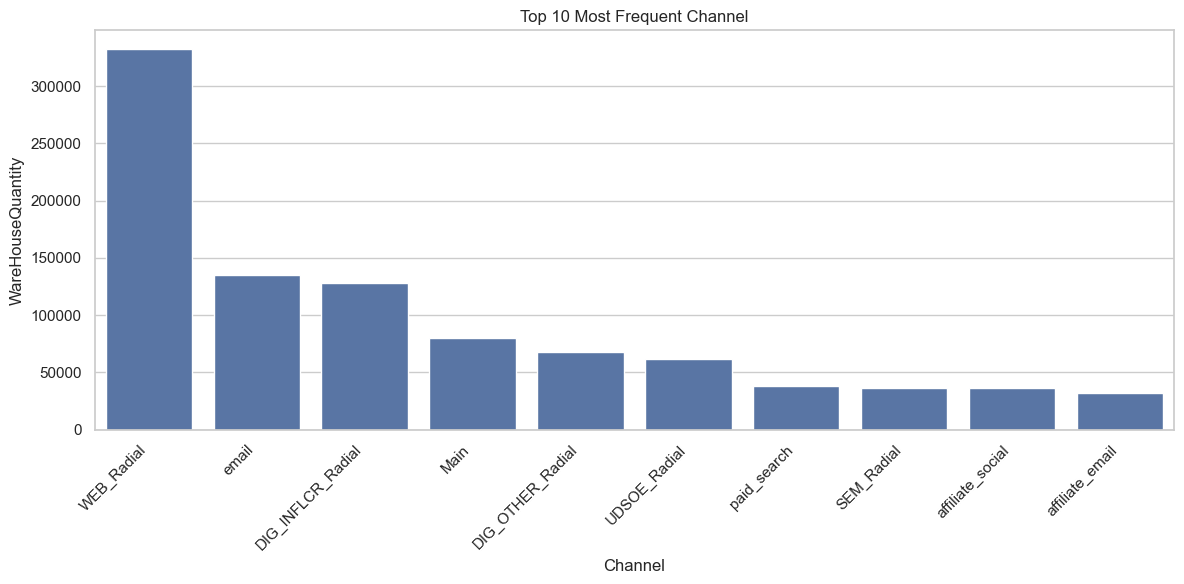

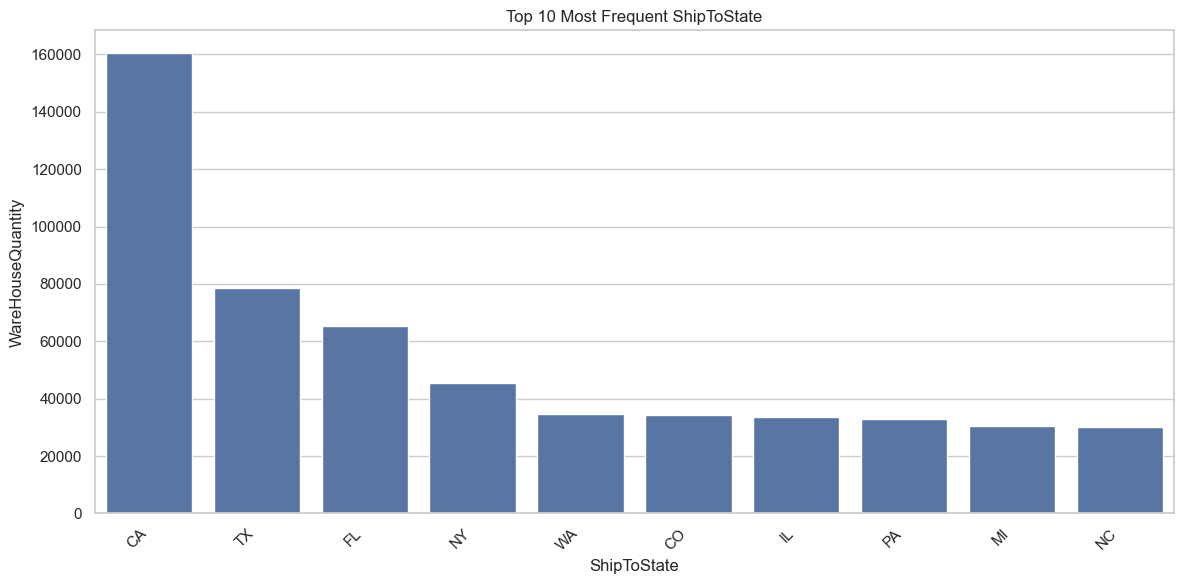

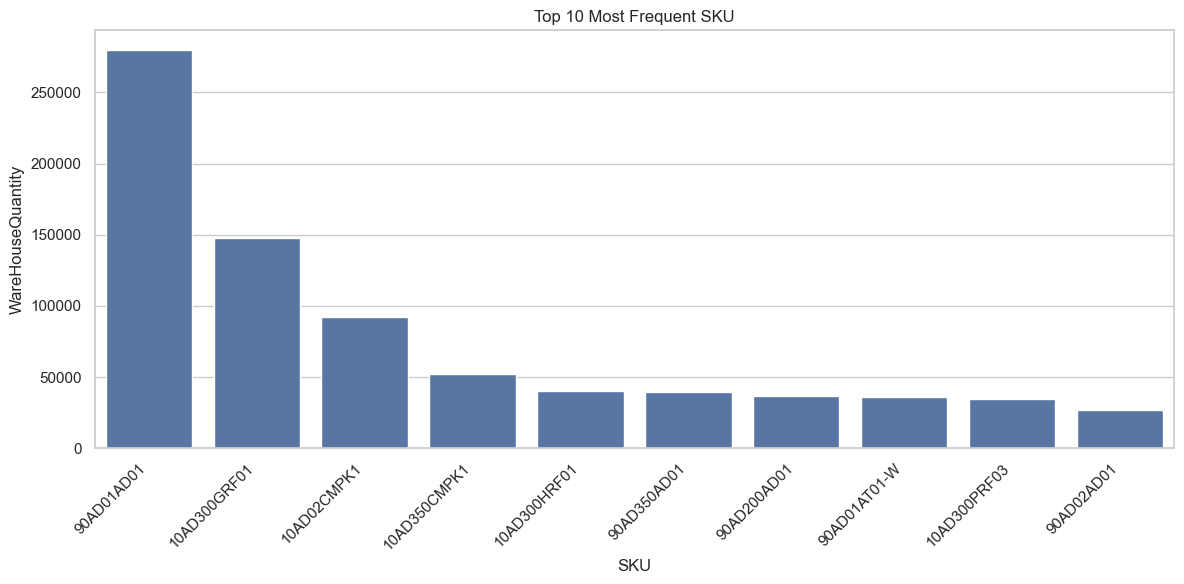

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_columns = ['ProductFamily', 'SKU_category', 'Channel', 'ShipToState','SKU']

for col in categorical_columns:
    plt.figure(figsize=(12, 6))  # Wider figure for long labels

    # Get top 10 most frequent categories
    top_10 = df[col].value_counts().nlargest(10).index
    filtered_df = df[df[col].isin(top_10)]

    # Plot
    ax = sns.countplot(data=filtered_df, x=col, order=top_10)
    plt.title(f"Top 10 Most Frequent {col}")
    plt.xlabel(col)
    plt.ylabel("WareHouseQuantity")

    # Rotate x-axis labels cleanly
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


### Step 4: Bivariate Analysis

**`SKU vs WareHouseQuantity`**

<Axes: xlabel='SKU'>

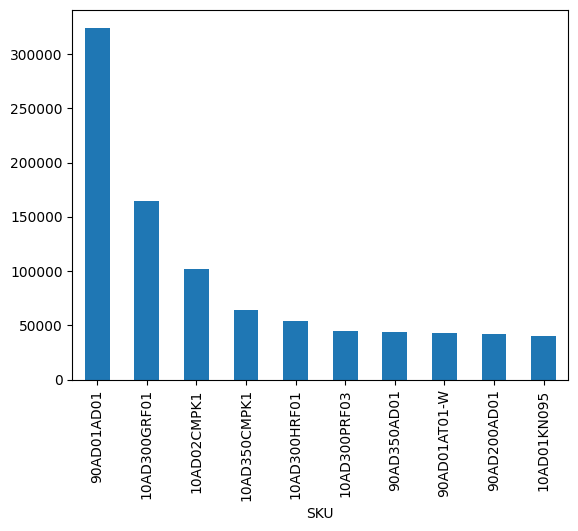

In [31]:
sku_qty = df.groupby('SKU')['WareHouseQuantity'].sum().sort_values(ascending=False).head(10)
sku_qty.plot(kind='bar')

<Axes: title={'center': 'Monthly Orders'}, xlabel='OrderDate'>

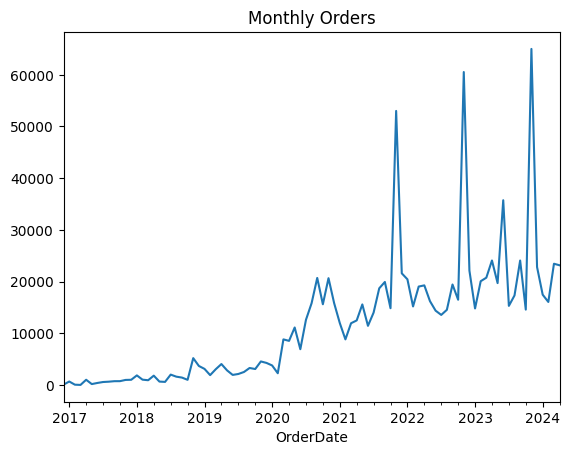

In [32]:
monthly_orders = df.groupby(df['OrderDate'].dt.to_period('M')).size()
monthly_orders.plot(kind='line', title='Monthly Orders')


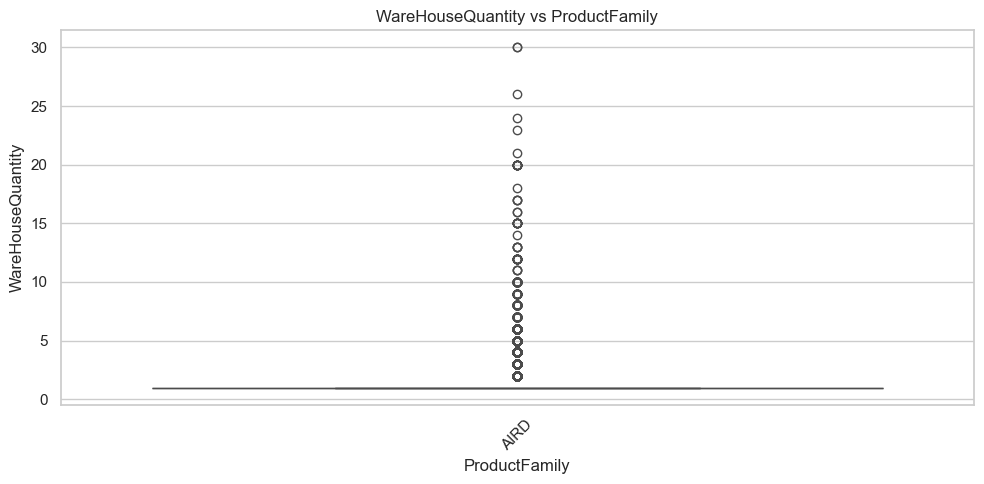

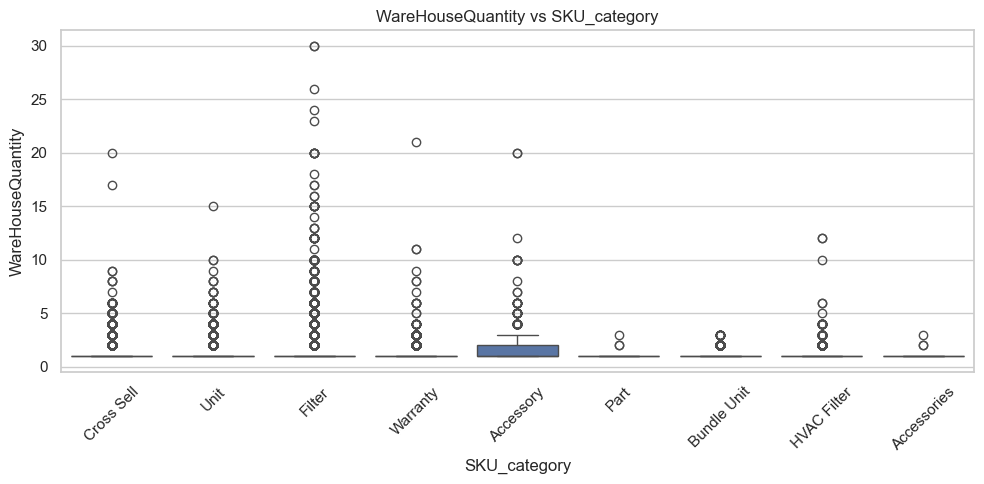

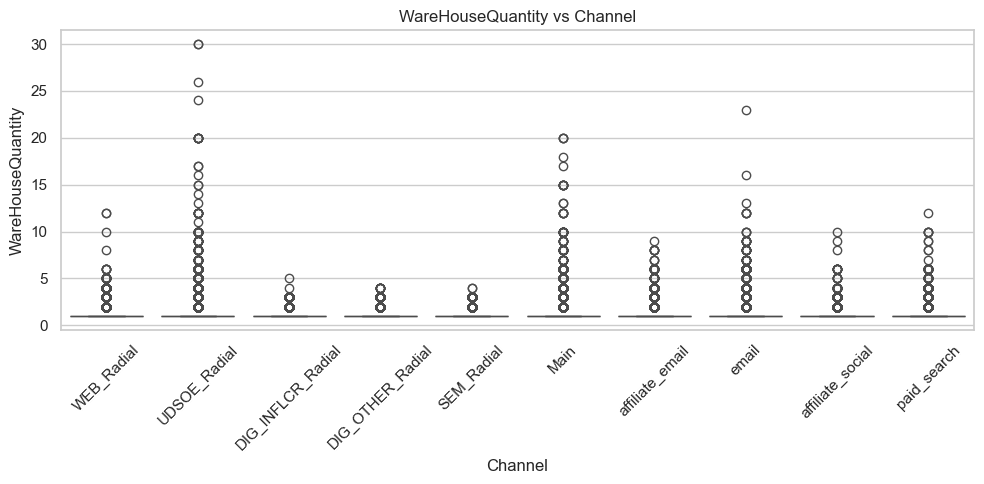

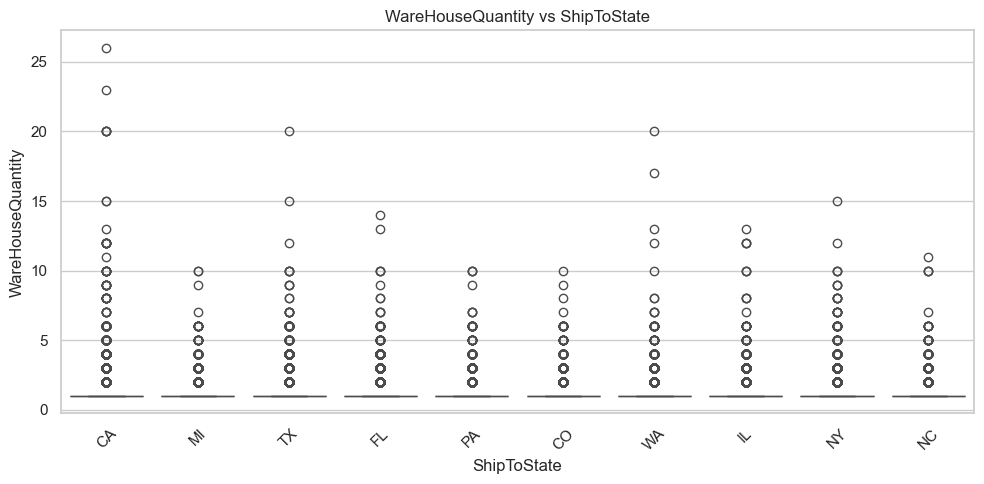

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set visual theme
sns.set(style='whitegrid')

# Categorical features
categorical_features = ['ProductFamily', 'SKU_category', 'Channel', 'ShipToState']

# Numerical features
numerical_features = ['OrderValue'] if 'OrderValue' in df.columns else []

# -----------------------------------------
# 1. Box plots for categorical vs WareHouseQuantity
# -----------------------------------------
for col in categorical_features:
    plt.figure(figsize=(10, 5))
    top_categories = df[col].value_counts().nlargest(10).index
    sns.boxplot(x=col, y='WareHouseQuantity', data=df[df[col].isin(top_categories)])
    plt.title(f'WareHouseQuantity vs {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# -----------------------------------------
# 2. Correlation heatmap for numerical features
# -----------------------------------------
if numerical_features:
    plt.figure(figsize=(6, 4))
    corr = df[numerical_features + ['WareHouseQuantity']].corr()
    sns.heatmap(corr, annot=True, cmap='Blues', fmt=".2f")
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.show()

# ------------------------------------


**`Which products are ordered the most, and through which channels?`**

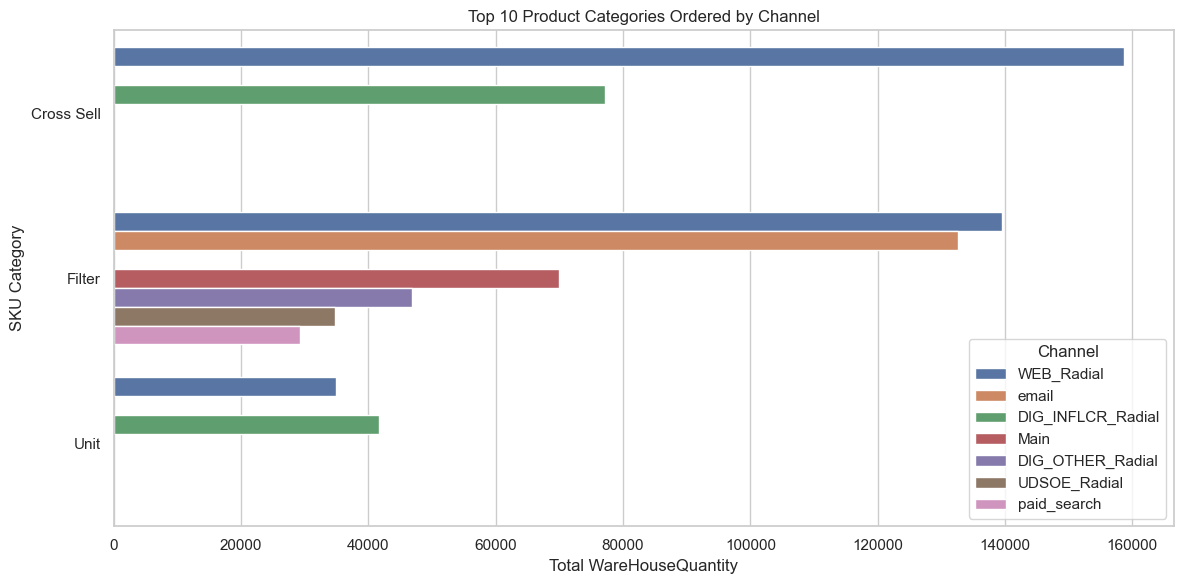

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Group by Channel and SKU_category, then sum WareHouseQuantity
category_channel = df.groupby(['Channel', 'SKU_category'])['WareHouseQuantity'].sum().reset_index()

# Sort to get top 10 overall combinations
top_10 = category_channel.sort_values(by='WareHouseQuantity', ascending=False).head(10)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=top_10, x='WareHouseQuantity', y='SKU_category', hue='Channel')
plt.title('Top 10 Product Categories Ordered by Channel')
plt.xlabel('Total WareHouseQuantity')
plt.ylabel('SKU Category')
plt.legend(title='Channel')
plt.tight_layout()
plt.show()


### Step 5: Multivariate Analysis

1. Heatmap **(Channel vs SKU_category vs Quantity)**
    - Shows how quantity varies for each category across different channels:


horizontal bar chart that visualizes the **total WareHouseQuantity** for each **SKU_category across different Channels.**

1. Which SKU categories are ordered the most overall?
    - From the heatmap (and general observation):
        - **Filter, Cross Sell, and Unit** categories dominate in terms of overall quantity.
        - Filter has values like 150,000, 125,000 across channels.
        - Cross Sell also shows very high totals — 145,000, 117,000+ in some channels.
        - Unit follows closely with quantities above 100,000.

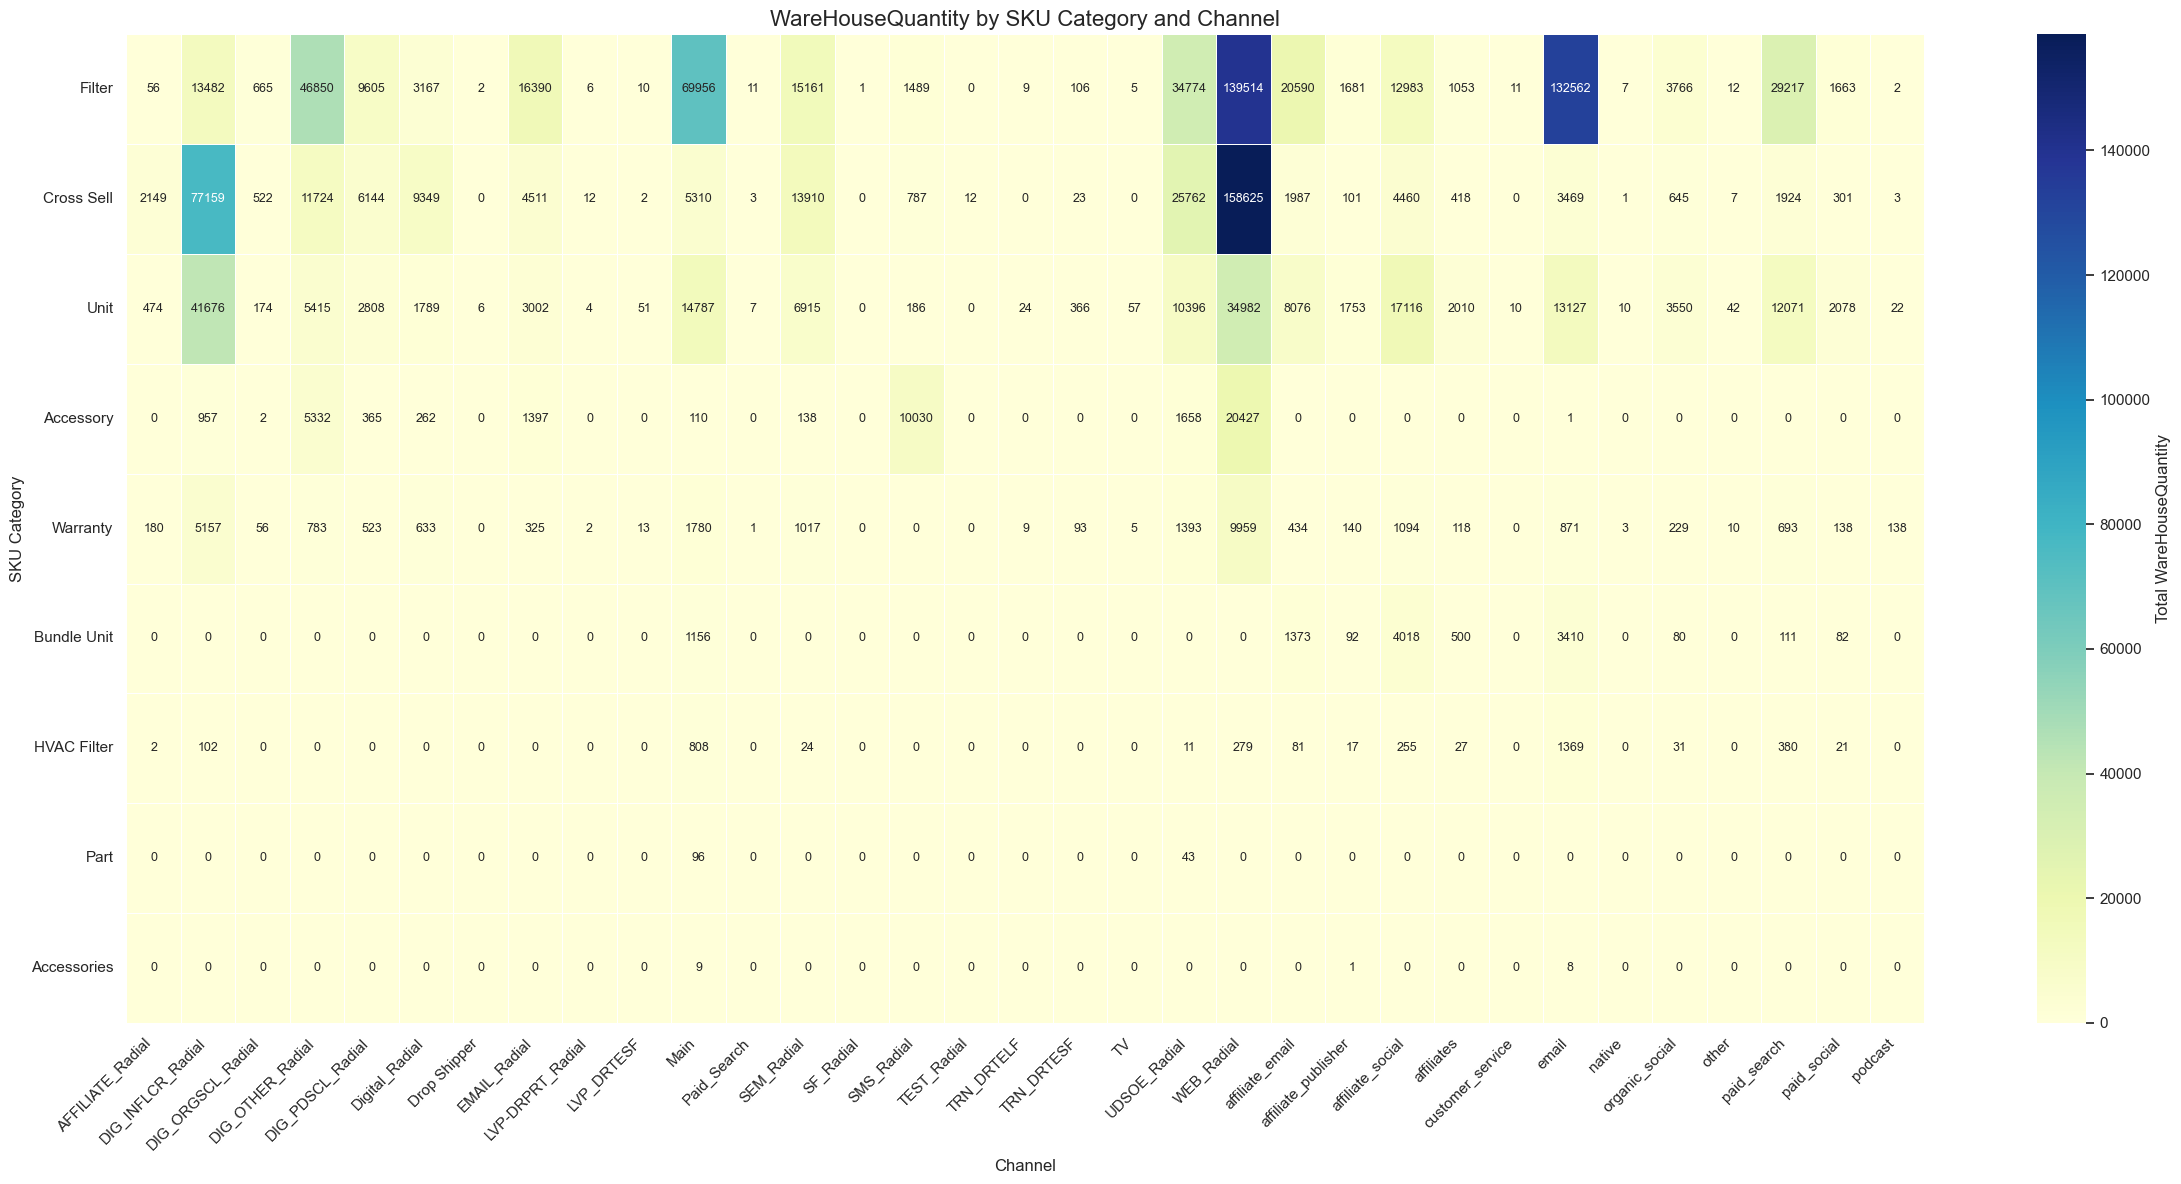

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create pivot table
pivot_table = df.pivot_table(
    values='WareHouseQuantity',
    index='SKU_category',
    columns='Channel',
    aggfunc='sum',
    fill_value=0
)

# Sort rows by total quantity
pivot_table = pivot_table.loc[pivot_table.sum(axis=1).sort_values(ascending=False).index]

# Plot
plt.figure(figsize=(24, 12))  # Bigger figure for more space
sns.heatmap(
    pivot_table,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu',
    linewidths=0.5,
    annot_kws={"size": 9},  # Larger annotation font
    cbar_kws={'label': 'Total WareHouseQuantity'}
)

plt.title('WareHouseQuantity by SKU Category and Channel', fontsize=16)
plt.xlabel('Channel', fontsize=12)
plt.ylabel('SKU Category', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels
plt.yticks(rotation=0)  # Keep y-axis labels horizontal
plt.tight_layout()
plt.show()


### Step 6: Feature Engineering
- **`Creating new features Week, Month, Year, DayOfWeek`**

In [36]:
# Convert 'OrderDate' to datetime format and extract week, month, year, and day of week
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['Week'] = df['OrderDate'].dt.to_period('W').apply(lambda r: r.start_time)
df['Month'] = df['OrderDate'].dt.month
df['Year'] = df['OrderDate'].dt.year
df['DayOfWeek'] = df['OrderDate'].dt.day_name()


In [37]:
df.head()

,ProductFamily,Order_ID,OrderDate,SKU_Description,WareHouseQuantity,SKU,SKU_category,Channel,ShipToState,ShippingZip,Week,Month,Year,DayOfWeek
0,AIRD,54522457,2016-12-23,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,CA,91403,2016-12-19,12,2016,Friday
1,AIRD,54526264,2016-12-28,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,CA,91326,2016-12-26,12,2016,Wednesday
2,AIRD,54536438,2016-12-30,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,DE,19806,2016-12-26,12,2016,Friday
3,AIRD,54536647,2016-12-31,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,CA,94903,2016-12-26,12,2016,Saturday
4,AIRD,54537034,2016-12-31,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,MI,48310,2016-12-26,12,2016,Saturday


**`On which day of the week do we get the highest Warehouse Quantity?`**

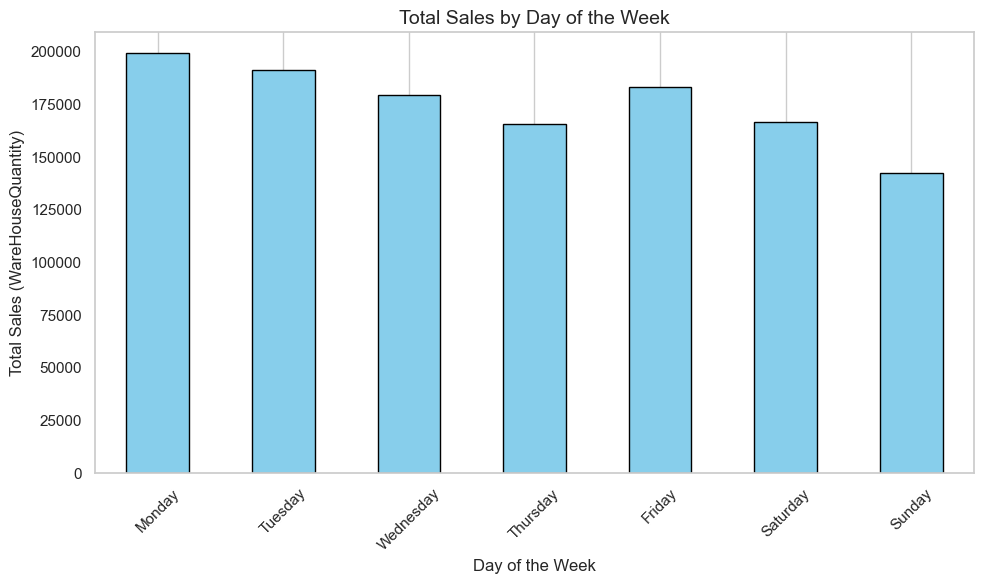

In [38]:
import matplotlib.pyplot as plt

# Clean up any typos in DayOfWeek
df["DayOfWeek"] = df["DayOfWeek"].str.strip().replace({"Saturda": "Saturday"})

# Group by DayOfWeek and sum the sales
sales_by_day = df.groupby("DayOfWeek")["WareHouseQuantity"].sum()

# Reorder days properly for plotting
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sales_by_day = sales_by_day.reindex(days_order)

# Plot the results
plt.figure(figsize=(10, 6))
sales_by_day.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Total Sales by Day of the Week", fontsize=14)
plt.xlabel("Day of the Week", fontsize=12)
plt.ylabel("Total Sales (WareHouseQuantity)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


**`Create a new feature to indicate high volume sales`**

This feature will be 1 if WareHouseQuantity is greater than a threshold (e.g., 5), otherwise 0

In [39]:
# Create a new feature to indicate high volume sales
# This feature will be 1 if WareHouseQuantity is greater than a threshold (e.g., 5), otherwise 0
df["HighVolumeSale"] = df["WareHouseQuantity"].apply(lambda x: 1 if x > 5 else 0)


In [40]:
# Filter the DataFrame to get only high volume sales
# This will create a new DataFrame with only those rows where HighVolumeSale is 1
high_value_df =df[df["HighVolumeSale"]==1]
high_value_df

,ProductFamily,Order_ID,OrderDate,SKU_Description,WareHouseQuantity,SKU,SKU_category,Channel,ShipToState,ShippingZip,Week,Month,Year,DayOfWeek,HighVolumeSale
5404,AIRD,55829308,2017-11-16,AD3000 Pre-Filter 3pk,6.0,10AD300PRF03,Filter,UDSOE_Radial,OR,97202,2017-11-13,11,2017,Thursday,1
14966,AIRD,56896008,2018-07-07,Air Doctor AD3000,7.0,90AD01AD01,Cross Sell,UDSOE_Radial,TN,37862,2018-07-02,7,2018,Saturday,1
18837,AIRD,57181375,2018-09-24,AD3000 HEPA Filter,6.0,10AD300HRF01,Filter,UDSOE_Radial,TX,78258,2018-09-24,9,2018,Monday,1
22166,AIRD,57381433,2018-11-23,Air Doctor AD3000,6.0,90AD01AD01,Cross Sell,UDSOE_Radial,CA,96073,2018-11-19,11,2018,Friday,1
25506,AIRD,57430254,2018-12-03,Air Doctor AD3000,6.0,90AD01AD01,Cross Sell,UDSOE_Radial,MI,48150,2018-12-03,12,2018,Monday,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045577,AIRD,280480,2024-04-26,AD2000 1-Year Filter Pack,6.0,10AD200CMPK1,Filter,paid_search,TX,76712,2024-04-22,4,2024,Friday,1
1046072,AIRD,281077,2024-04-27,AD3500 1-Year Filter Combo Pack,6.0,10AD350CMPK1,Filter,Main,CA,95628,2024-04-22,4,2024,Saturday,1
1047661,AIRD,282438,2024-04-29,AD3500 1-Year Filter Combo Pack,7.0,10AD350CMPK1,Filter,email,MN,55901,2024-04-29,4,2024,Monday,1
1047906,AIRD,282534,2024-04-29,AD1000 Tower Filter (2-in-1),6.0,10AD01TF01,Filter,email,AZ,85140,2024-04-29,4,2024,Monday,1


**`2. Weekend vs Weekday`**

Helps to analyze if sales are more during **weekends.**

Indicate whether a particular sale occurred on a **weekend (Saturday or Sunday).**
- IsWeekend: 1
- Otherwise: 0

In [41]:
df["IsWeekend"] = df["DayOfWeek"].isin(["Saturday", "Sunday"]).astype(int)

In [42]:
df.head()

,ProductFamily,Order_ID,OrderDate,SKU_Description,WareHouseQuantity,SKU,SKU_category,Channel,ShipToState,ShippingZip,Week,Month,Year,DayOfWeek,HighVolumeSale,IsWeekend
0,AIRD,54522457,2016-12-23,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,CA,91403,2016-12-19,12,2016,Friday,0,0
1,AIRD,54526264,2016-12-28,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,CA,91326,2016-12-26,12,2016,Wednesday,0,0
2,AIRD,54536438,2016-12-30,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,DE,19806,2016-12-26,12,2016,Friday,0,0
3,AIRD,54536647,2016-12-31,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,CA,94903,2016-12-26,12,2016,Saturday,0,1
4,AIRD,54537034,2016-12-31,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,MI,48310,2016-12-26,12,2016,Saturday,0,1


Overall weekend vs weekday order volume

In [80]:
weekend_summary = df.groupby("IsWeekend")["WareHouseQuantity"].sum().reset_index()
weekend_summary["DayType"] = weekend_summary["IsWeekend"].map({0: "Weekday", 1: "Weekend"})
print(weekend_summary)


   IsWeekend  WareHouseQuantity  DayType
0          0           919090.0  Weekday
1          1           309195.0  Weekend


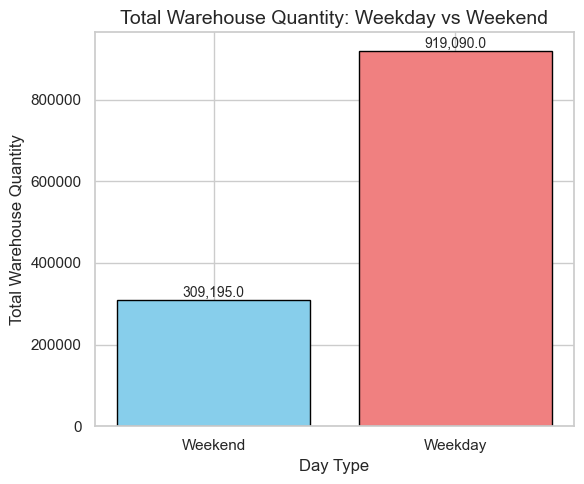

In [98]:
import matplotlib.pyplot as plt

# Sample data: weekend_summary already prepared
# weekend_summary = df.groupby("IsWeekend")["WareHouseQuantity"].sum().reset_index()
# weekend_summary["DayType"] = weekend_summary["IsWeekend"].map({0: "Weekday", 1: "Weekend"})

# Plot
plt.figure(figsize=(6, 5))
bars = plt.bar(
    weekend_summary["DayType"], 
    weekend_summary["WareHouseQuantity"], 
    color=["skyblue", "lightcoral"], 
    edgecolor="black"
)

# Add values on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval:,}", ha="center", va="bottom", fontsize=10)

plt.title("Total Warehouse Quantity: Weekday vs Weekend", fontsize=14)
plt.ylabel("Total Warehouse Quantity")
plt.xlabel("Day Type")
plt.tight_layout()
plt.show()


C:\Users\Nilam Wadhavane\AppData\Local\Temp\ipykernel_24112\1719786342.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




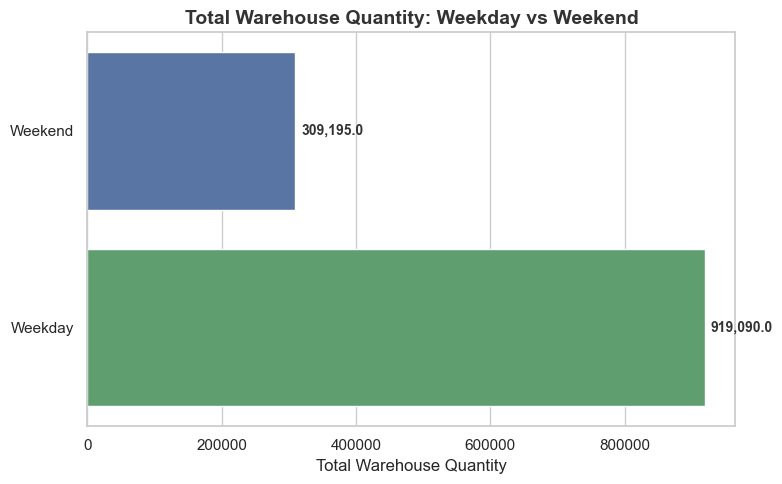

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sample weekend_summary DataFrame (use your actual one)
# weekend_summary = df.groupby("IsWeekend")["WareHouseQuantity"].sum().reset_index()
# weekend_summary["DayType"] = weekend_summary["IsWeekend"].map({0: "Weekday", 1: "Weekend"})

# Set style
sns.set_style("whitegrid")
plt.figure(figsize=(8, 5))

# Sort so highest value is on top
weekend_summary = weekend_summary.sort_values(by="WareHouseQuantity", ascending=True)

# Create horizontal barplot
bar_colors = ["#4C72B0", "#55A868"]  # Professional muted tones
sns.barplot(
    data=weekend_summary,
    y="DayType",
    x="WareHouseQuantity",
    palette=bar_colors
)

# Add annotations for quantities
for i, v in enumerate(weekend_summary["WareHouseQuantity"]):
    plt.text(v + (max(weekend_summary["WareHouseQuantity"]) * 0.01), i, f"{v:,}", 
             va="center", fontsize=10, fontweight="bold", color="#333333")

# Titles & labels
plt.title("Total Warehouse Quantity: Weekday vs Weekend", fontsize=14, fontweight="bold", color="#333333")
plt.xlabel("Total Warehouse Quantity", fontsize=12)
plt.ylabel("")
plt.tight_layout()

plt.show()


Average order quantity per day type

In [81]:
avg_quantity = df.groupby("IsWeekend")["WareHouseQuantity"].mean().reset_index()
avg_quantity["DayType"] = avg_quantity["IsWeekend"].map({0: "Weekday", 1: "Weekend"})
print(avg_quantity)


   IsWeekend  WareHouseQuantity  DayType
0          0           1.179383  Weekday
1          1           1.169762  Weekend


Channel performance on weekends vs weekdays

In [86]:
channel_weekend = df.groupby(["Channel", "IsWeekend"])["WareHouseQuantity"].sum().unstack().fillna(0)

channel_weekend = channel_weekend.rename(columns={0:"Weekday", 1: "Weekend"})
print(channel_weekend)


IsWeekend             Weekday   Weekend
Channel                                
AFFILIATE_Radial       2120.0     746.0
DIG_INFLCR_Radial    108459.0   33463.0
DIG_ORGSCL_Radial      1133.0     461.0
DIG_OTHER_Radial      60352.0   20581.0
DIG_PDSCL_Radial      15739.0    6463.0
Digital_Radial        10720.0    4597.0
Drop Shipper              8.0       0.0
EMAIL_Radial          20419.0    9576.0
LVP-DRPRT_Radial         19.0       5.0
LVP_DRTESF               59.0      17.0
Main                  75780.0   19227.0
Paid_Search              19.0       3.0
SEM_Radial            30405.0   11435.0
SF_Radial                 1.0       0.0
SMS_Radial             8330.0    4276.0
TEST_Radial               0.0      12.0
TRN_DRTELF               37.0       5.0
TRN_DRTESF              416.0     172.0
TV                       41.0      26.0
UDSOE_Radial          69841.0    7273.0
WEB_Radial           283904.0  106027.0
affiliate_email       28400.0    9008.0
affiliate_publisher    2728.0    1078.0


Which Channels Performed Well on Weekends?

On weekends, WEB_Radial brings in the most orders by far, followed by email and DIG_INFLCR_Radial. Smaller channels like affiliate_email and affiliate_social also do well, but their order volumes are much lower than the top three.


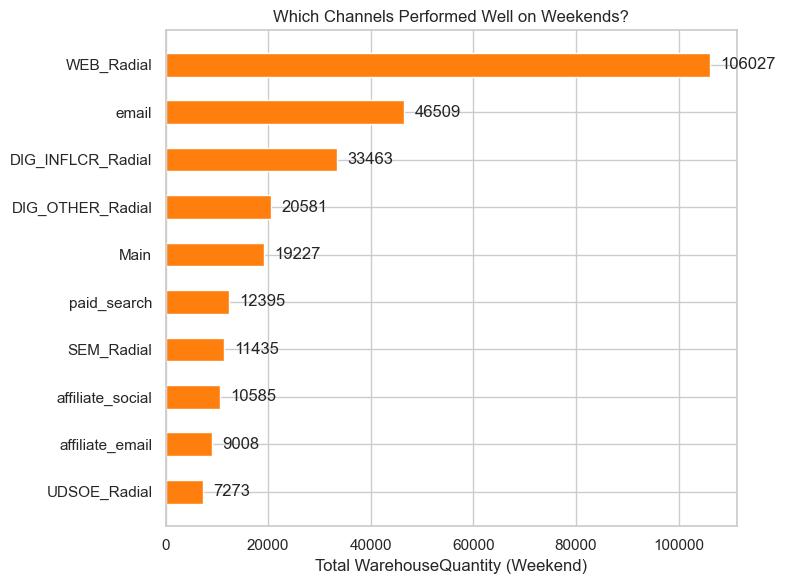

In [106]:
import matplotlib.pyplot as plt
import numpy as np

# Sort channels by Weekend orders and keep top 10
channel_weekend = channel_weekend.sort_values("Weekend", ascending=True).head(10)

# Data for plotting
channels = channel_weekend.index
weekend_values = channel_weekend["Weekend"]

# Bar positions
y = np.arange(len(channels))

# Plot
fig, ax = plt.subplots(figsize=(8,6))
ax.barh(y, weekend_values, color="#ff7f0e", height=0.5)

# Labels and title
ax.set_yticks(y)
ax.set_yticklabels(channels)
ax.set_xlabel("Total WarehouseQuantity (Weekend)")
ax.set_title("Which Channels Performed Well on Weekends?")

# Show values on bars
for i, v in enumerate(weekend_values):
    ax.text(v + 2000, i, str(int(v)), va='center')

plt.tight_layout()
plt.show()


Which Channels Performed Well on Weekdays?

- On weekdays, WEB_Radial leads by a wide margin with the most orders, followed by email and DIG_INFLCR_Radial.
Channels like Main and UDSOE_Radial also perform well, while others such as DIG_OTHER_Radial, paid_search, SEM_Radial, affiliate_social, and affiliate_email bring in smaller but steady volumes. Overall, a few key channels drive most of the weekday orders.


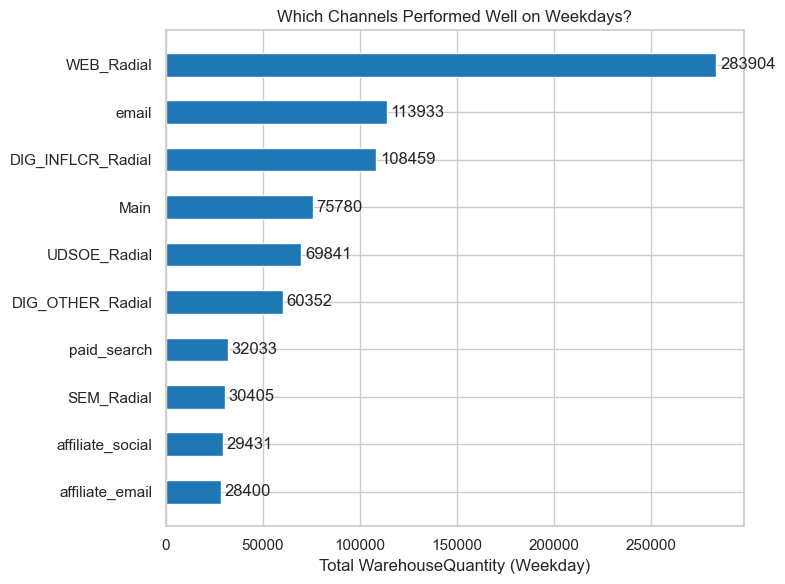

In [109]:
import matplotlib.pyplot as plt
import numpy as np

# Sort channels by Weekday orders and keep top 10
channel_weekday = channel_weekend.sort_values("Weekday", ascending=True).head(10)

# Data for plotting
channels = channel_weekday.index
weekday_values = channel_weekday["Weekday"]

# Bar positions
y = np.arange(len(channels))

# Plot
fig, ax = plt.subplots(figsize=(8,6))
ax.barh(y, weekday_values, color="#1f77b4", height=0.5)

# Labels and title
ax.set_yticks(y)
ax.set_yticklabels(channels)
ax.set_xlabel("Total WarehouseQuantity (Weekday)")
ax.set_title("Which Channels Performed Well on Weekdays?")

# Show values on bars
for i, v in enumerate(weekday_values):
    ax.text(v + 2000, i, str(int(v)), va='center')

plt.tight_layout()
plt.show()


This chart compares the top 10 sales channels for weekday and weekend orders. 

- Weekends: Most orders come through WEB_Radial, followed by email and DIG_INFLCR_Radial.
- Weekdays: WEB_Radial again leads by a large margin, followed by email and DIG_INFLCR_Radial.

In both cases, WEB_Radial is the dominant channel, but order volumes are much higher on weekdays than weekends.






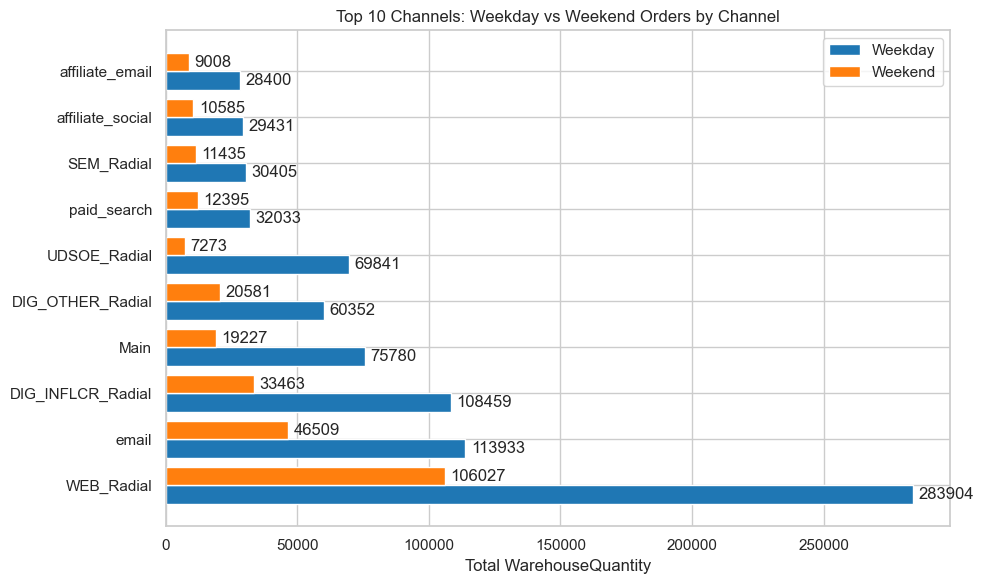

In [93]:
import matplotlib.pyplot as plt
import numpy as np

# Sort channels by total orders and keep top 10
channel_weekend["Total"] = channel_weekend["Weekday"] + channel_weekend["Weekend"]
channel_weekend = channel_weekend.sort_values("Total", ascending=False).head(10).drop(columns="Total")

# Data for plotting
channels = channel_weekend.index
weekday_values = channel_weekend["Weekday"]
weekend_values = channel_weekend["Weekend"]

# Bar positions
bar_width = 0.4
y = np.arange(len(channels))

# Plot
fig, ax = plt.subplots(figsize=(10,6))
ax.barh(y - bar_width/2, weekday_values, height=bar_width, label="Weekday", color="#1f77b4")
ax.barh(y + bar_width/2, weekend_values, height=bar_width, label="Weekend", color="#ff7f0e")

# Labels and title
ax.set_yticks(y)
ax.set_yticklabels(channels)
ax.set_xlabel("Total WarehouseQuantity")
ax.set_title("Top 10 Channels: Weekday vs Weekend Orders by Channel")
ax.legend()

# Show values on bars
for i, v in enumerate(weekday_values):
    ax.text(v + 2000, i - bar_width/2, str(int(v)), va='center')
for i, v in enumerate(weekend_values):
    ax.text(v + 2000, i + bar_width/2, str(int(v)), va='center')

plt.tight_layout()
plt.show()


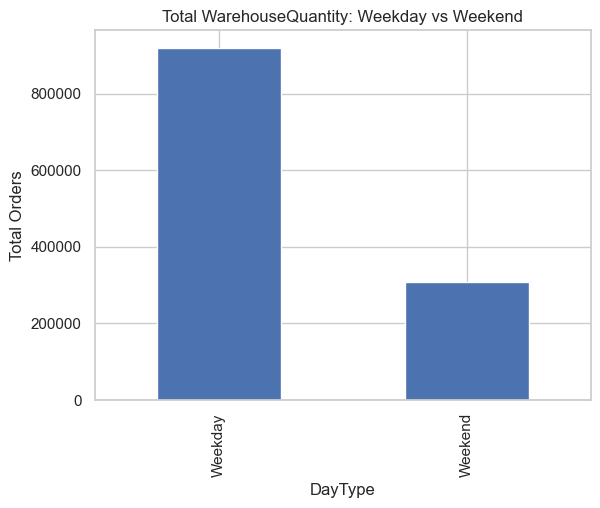

In [87]:
import matplotlib.pyplot as plt

weekend_summary.plot(x="DayType", y="WareHouseQuantity", kind="bar", legend=False)
plt.title("Total WarehouseQuantity: Weekday vs Weekend")
plt.ylabel("Total Orders")
plt.show()


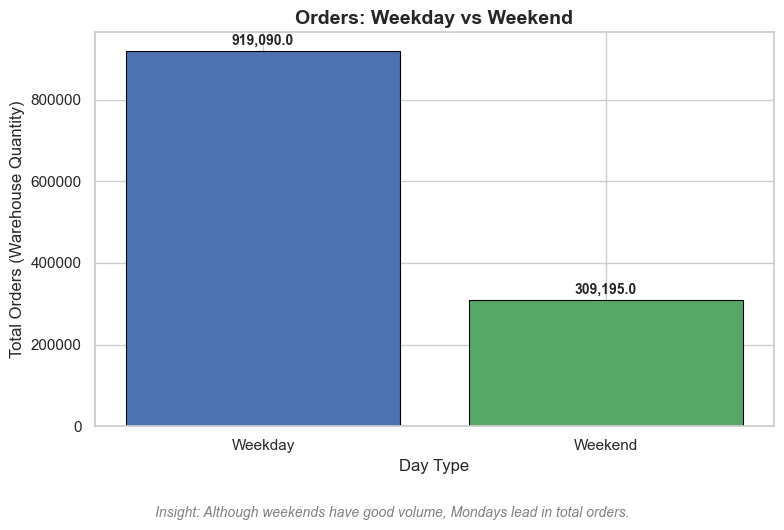

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data
weekend_summary = df.groupby("IsWeekend")["WareHouseQuantity"].sum().reset_index()
weekend_summary["DayType"] = weekend_summary["IsWeekend"].map({0: "Weekday", 1: "Weekend"})

# Professional style
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")
bar_colors = ["#4C72B0", "#55A868"]  # Professional muted blue/green

bars = plt.bar(
    weekend_summary["DayType"],
    weekend_summary["WareHouseQuantity"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.8
)

# Annotate values
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + (max(weekend_summary["WareHouseQuantity"])*0.01),
        f"{height:,}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Title & labels
plt.title("Orders: Weekday vs Weekend", fontsize=14, fontweight="bold")
plt.ylabel("Total Orders (Warehouse Quantity)", fontsize=12)
plt.xlabel("Day Type", fontsize=12)

# Highlight insight
plt.figtext(
    0.5, -0.05,
    "Insight: Although weekends have good volume, Mondays lead in total orders.",
    ha="center", fontsize=10, style="italic", color="gray"
)

plt.tight_layout()
plt.show()


In [100]:
import pandas as pd

# Ensure OrderDate is datetime
df["OrderDate"] = pd.to_datetime(df["OrderDate"])

# Extract week number and day name
df["Week"] = df["OrderDate"].dt.isocalendar().week
df["Year"] = df["OrderDate"].dt.year
df["DayName"] = df["OrderDate"].dt.day_name()

# Weekly totals by day
weekly_totals = df.groupby(["Year", "Week", "DayName"])["WareHouseQuantity"].sum().reset_index()

# Find the max day for each week
max_per_week = weekly_totals.loc[weekly_totals.groupby(["Year", "Week"])["WareHouseQuantity"].idxmax()]

# Count how many times Monday is the top day
monday_top_count = (max_per_week["DayName"] == "Monday").sum()
total_weeks = max_per_week.shape[0]
percentage_monday_top = (monday_top_count / total_weeks) * 100

print(f"Monday was the highest in {monday_top_count} out of {total_weeks} weeks ({percentage_monday_top:.2f}%).")

# Display which days were top for each week
print(max_per_week.sort_values(["Year", "Week"]))


Monday was the highest in 107 out of 386 weeks (27.72%).
      Year  Week    DayName  WareHouseQuantity
0     2016    51     Friday                1.0
2     2016    52   Saturday               73.0
5     2017     1     Monday               54.0
15    2017     2   Thursday              175.0
19    2017     3     Monday               18.0
...    ...   ...        ...                ...
2620  2024    14  Wednesday             1917.0
2622  2024    15     Monday             1839.0
2629  2024    16     Monday             1125.0
2641  2024    17  Wednesday             1270.0
2642  2024    18     Monday             1208.0

[386 rows x 4 columns]


**`Season Feature`**

Categorize sales by season using month:

In [43]:
# Create a new feature Season based on the Month
# This will categorize the month into seasons: Winter, Spring, Summer, Fall

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'
df["Season"] = df["Month"].apply(get_season)

In [44]:
df.head()

,ProductFamily,Order_ID,OrderDate,SKU_Description,WareHouseQuantity,SKU,SKU_category,Channel,ShipToState,ShippingZip,Week,Month,Year,DayOfWeek,HighVolumeSale,IsWeekend,Season
0,AIRD,54522457,2016-12-23,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,CA,91403,2016-12-19,12,2016,Friday,0,0,Winter
1,AIRD,54526264,2016-12-28,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,CA,91326,2016-12-26,12,2016,Wednesday,0,0,Winter
2,AIRD,54536438,2016-12-30,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,DE,19806,2016-12-26,12,2016,Friday,0,0,Winter
3,AIRD,54536647,2016-12-31,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,CA,94903,2016-12-26,12,2016,Saturday,0,1,Winter
4,AIRD,54537034,2016-12-31,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,MI,48310,2016-12-26,12,2016,Saturday,0,1,Winter


**`WareHouseQuantity by Season`**
- Which shows total sales for each season in below plot you can see that fall has the highest sales.

In [45]:
# Group by Season and sum WareHouseQuantity
season_sales = df.groupby("Season")["WareHouseQuantity"].sum()

# Sort values (optional, for better visibility)
season_sales = season_sales.sort_values(ascending=False)

# Display the result
print(season_sales)


Season
Fall      429169.0
Spring    290970.0
Winter    270183.0
Summer    237963.0
Name: WareHouseQuantity, dtype: float64


Which Season Has the Highest Warehouse Quantity?

The chart clearly shows that Fall leads all other seasons in total warehouse quantity, with 429,169 units.

Here are the insights:
- Fall significantly outperforms other seasons, having about 47% more stock than the lowest season (Summer).
- Spring follows in second place with 290,970 units, showing strong but notably lower performance than Fall.
- Winter is close to Spring at 270,183 units, indicating relatively stable mid-range warehouse activity.
- Summer ranks lowest with 237,963 units, suggesting reduced demand or stocking activity during this period.

Key takeaway: Fall is the peak season for warehouse quantity, possibly due to higher pre-holiday stocking or seasonal demand, while Summer shows the lowest activity. 


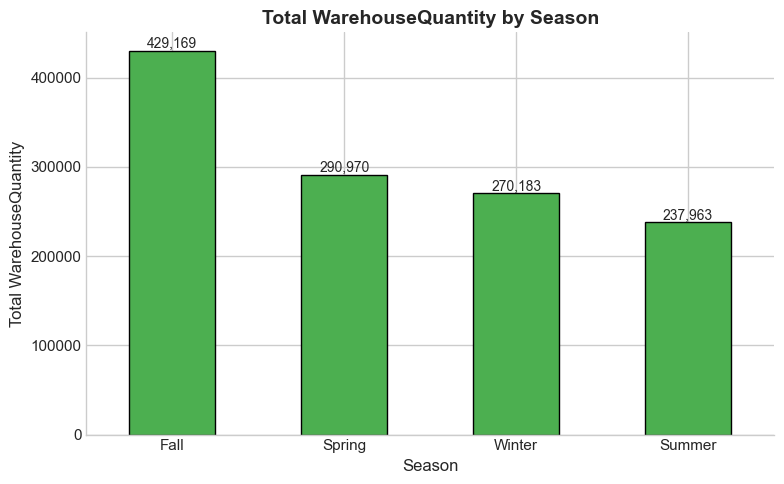

In [114]:
import matplotlib.pyplot as plt

# Style settings
plt.style.use("seaborn-v0_8-whitegrid")

# Create plot
fig, ax = plt.subplots(figsize=(8, 5))
bars = season_sales.plot(
    kind='bar',
    color='#4CAF50',  # Professional green
    edgecolor='black',
    ax=ax
)

# Titles and labels
ax.set_title("Total WarehouseQuantity by Season", fontsize=14, fontweight='bold')
ax.set_xlabel("Season", fontsize=12)
ax.set_ylabel("Total WarehouseQuantity", fontsize=12)
ax.set_xticklabels(season_sales.index, rotation=0, fontsize=11)
ax.tick_params(axis='y', labelsize=11)

# Show values above bars
for i, value in enumerate(season_sales):
    ax.text(i, value + (value * 0.01), f"{int(value):,}", ha='center', fontsize=10)

# Remove top & right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


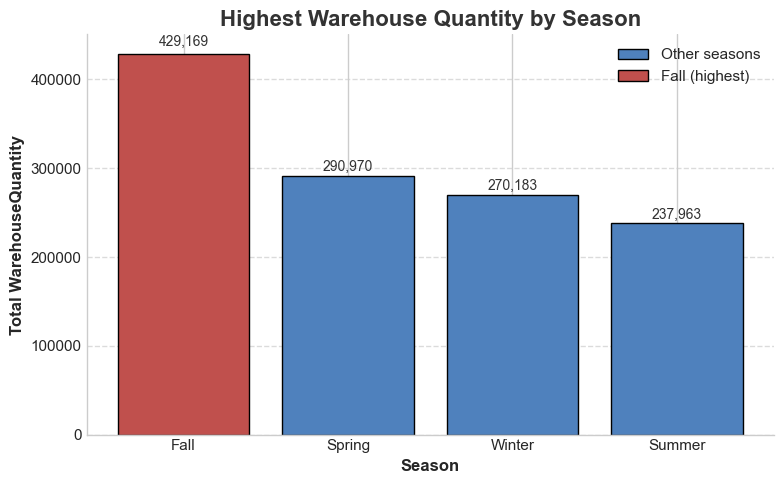

In [117]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.style.use("seaborn-v0_8-whitegrid")

# Highlight "Fall" with a different color
colors = ['#4F81BD' if season != 'Fall' else '#C0504D' for season in season_sales.index]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(season_sales.index, season_sales.values, color=colors, edgecolor='black')

# Titles & labels
ax.set_title("Highest Warehouse Quantity by Season", fontsize=16, fontweight='bold', color='#333333')
ax.set_xlabel("Season", fontsize=12, fontweight='semibold')
ax.set_ylabel("Total WarehouseQuantity", fontsize=12, fontweight='semibold')

# Legend (custom patches to avoid one entry per bar)
legend_handles = [
    Patch(facecolor='#4F81BD', edgecolor='black', label='Other seasons'),
    Patch(facecolor='#C0504D',  edgecolor='black', label='Fall (highest)')
]
ax.legend(handles=legend_handles, loc='upper right', frameon=False, fontsize=11)

# Grid for y-axis only
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Value labels above bars (with thousands separator)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + (height * 0.02),
            f"{int(height):,}", ha='center', fontsize=10, fontweight='medium', color='#333333')

# Remove unnecessary borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


**`Top 10 WareHouseQuantity by Season and SKU`**



In [125]:
# WareHouseQuantity by Season and SKU
season_sku_sales = df.groupby(["Season", "SKU"])["WareHouseQuantity"].sum().reset_index()
top10_season_sku = season_sku_sales.sort_values(by="WareHouseQuantity", ascending=False).head(30)

print(top10_season_sku)


     Season           SKU  WareHouseQuantity
61     Fall    90AD01AD01           101573.0
145  Spring    90AD01AD01            81067.0
217  Summer    90AD01AD01            71222.0
292  Winter    90AD01AD01            70652.0
20     Fall  10AD300GRF01            62393.0
100  Spring  10AD300GRF01            38209.0
12     Fall   10AD02CMPK1            38186.0
251  Winter  10AD300GRF01            32268.0
181  Summer  10AD300GRF01            31663.0
25     Fall  10AD350CMPK1            25209.0
92   Spring   10AD02CMPK1            24204.0
175  Summer   10AD02CMPK1            21059.0
245  Winter   10AD02CMPK1            18400.0
68     Fall   90AD350AD01            18319.0
22     Fall  10AD300HRF01            18116.0
23     Fall  10AD300PRF03            17390.0
66     Fall   90AD200AD01            16044.0
256  Winter  10AD350CMPK1            15092.0
172  Summer   10AD01KN095            14757.0
105  Spring  10AD350CMPK1            14236.0
102  Spring  10AD300HRF01            14046.0
11     Fal

Key Observations:
- Fall dominates overall inventory
- The SKU 90AD01AD01 (pink bars) has the highest warehouse quantity in every season, especially in Fall (over 100,000 units).
- Fall is the peak season for multiple SKUs, not just the top-selling one.
- This makes sense because Fall includes Black Friday and the start of the holiday shopping season, leading to stock build-up.

Seasonal trends for major SKUs

- 90AD01AD01: Gradually decreases from Fall → Spring → Summer/Winter but still remains very high in all seasons.
- 10AD300GRF01: Second highest overall, follows the same pattern — biggest in Fall, lowest in Spring/Summer, slightly higher in Winter.
- 10AD02CMPK1: Consistent across seasons but with a clear Fall peak.
- 10AD350CMPK1 & 90AD350AD01: Significant drop from Fall to other seasons.

Spring & Summer dips

- Spring generally sees lower quantities for most SKUs compared to Fall, possibly because it’s after the holiday season and before major summer promotions.
- Summer is slightly higher than Spring for some SKUs (e.g., 10AD300PRF03, 10AD01KN095), maybe due to mid-year campaigns.

Winter builds stock for holiday demand

- Winter has higher levels than Spring for many SKUs, suggesting preparation for Christmas and New Year sales.
- However, still lower than Fall, which is the ultimate peak.

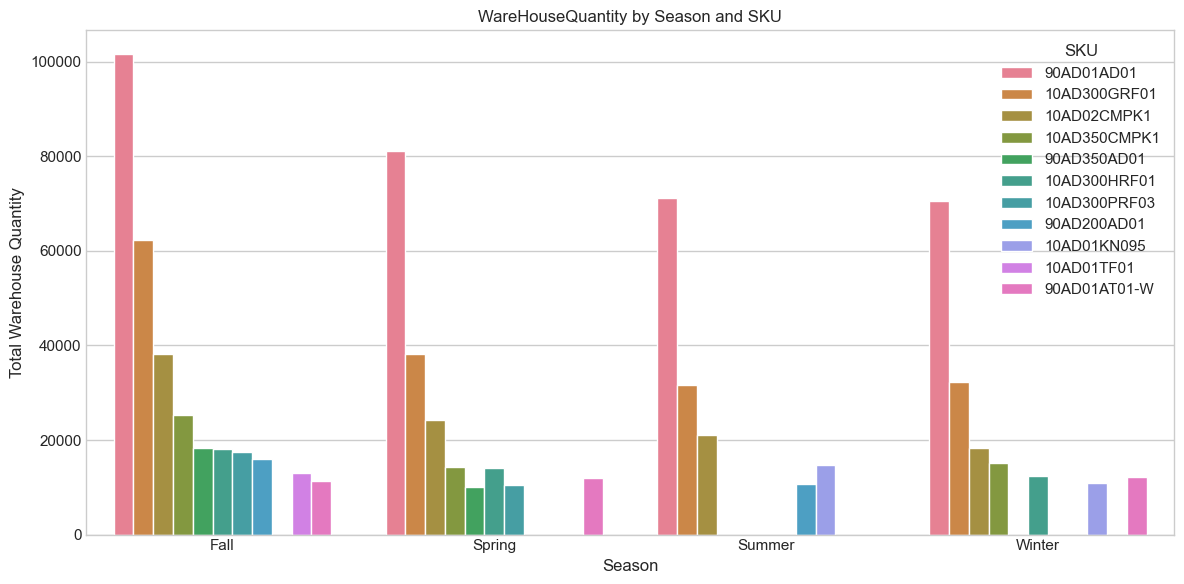

In [127]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.barplot(data=top10_season_sku, x="Season", y="WareHouseQuantity", hue="SKU")
plt.title("WareHouseQuantity by Season and SKU")
plt.ylabel("Total Warehouse Quantity")
plt.tight_layout()
plt.show()


**`Top 10 WareHouseQuantity by Season and Channel`**

In [132]:
season_channel_sales = df.groupby(["Season", "Channel"])["WareHouseQuantity"].sum().reset_index()
top10_season_channel = season_channel_sales.sort_values(by="WareHouseQuantity", ascending=False).head(20)

print(top10_season_channel)


    Season            Channel  WareHouseQuantity
14    Fall         WEB_Radial           119631.0
39  Spring         WEB_Radial            94894.0
93  Winter         WEB_Radial            90489.0
66  Summer         WEB_Radial            84917.0
19    Fall              email            62442.0
3     Fall   DIG_OTHER_Radial            49845.0
25  Spring  DIG_INFLCR_Radial            38944.0
53  Summer  DIG_INFLCR_Radial            38882.0
1     Fall  DIG_INFLCR_Radial            38291.0
45  Spring              email            38265.0
98  Winter              email            33794.0
15    Fall    affiliate_email            31191.0
32  Spring               Main            26717.0
9     Fall               Main            26620.0
71  Summer              email            25941.0
77  Winter  DIG_INFLCR_Radial            25805.0
13    Fall       UDSOE_Radial            24047.0
86  Winter               Main            23210.0
92  Winter       UDSOE_Radial            19615.0
22    Fall        pa

This chart shows total warehouse quantity grouped by season and sales channel.

Here’s what it’s telling us:

- WEB_Radial is by far the top-performing channel in every season, peaking in Fall with ~120,000 units.
- Fall overall has the highest total sales across most channels, especially WEB_Radial, email, and DIG_OTHER_Radial.
- Spring and Winter have similar WEB_Radial volumes (~90–95k), but Winter shows a slight drop in other channels.
- Summer has the lowest WEB_Radial numbers (~85k), but DIG_INFLCR_Radial remains strong, matching or beating Spring/Winter in that channel.
- Channels like paid_search, UDSOE_Radial, and affiliate_email are consistently lower contributors.

Key takeaway:
Most orders come from WEB_Radial in Fall, with email and influencer marketing also playing significant roles depending on the season.

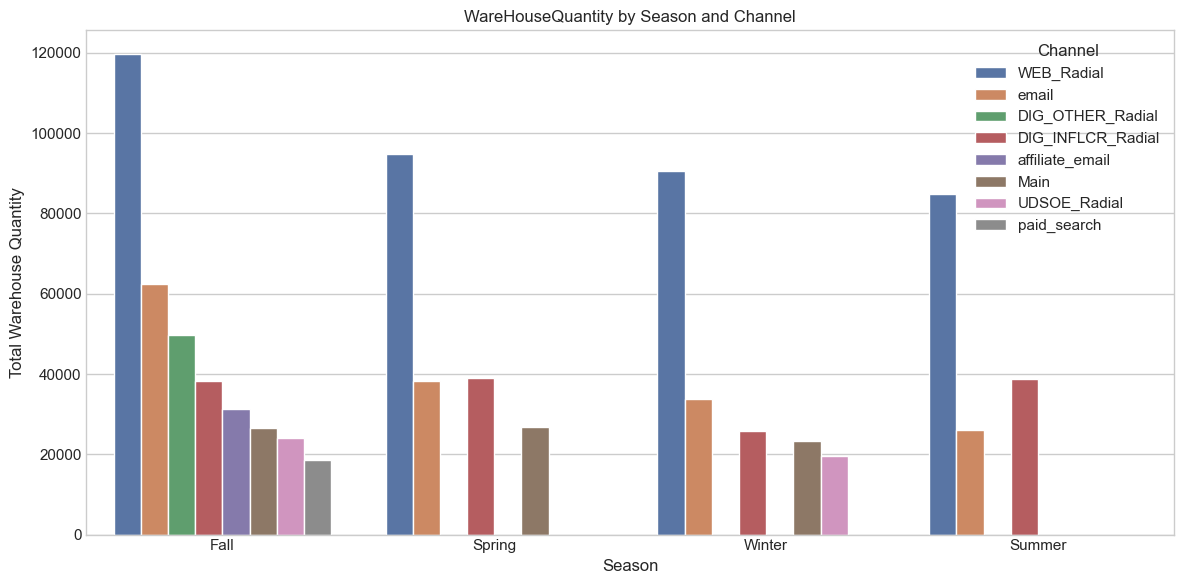

In [134]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.barplot(data=top10_season_channel, x="Season", y="WareHouseQuantity", hue="Channel")
plt.title("WareHouseQuantity by Season and Channel")
plt.ylabel("Total Warehouse Quantity")
plt.tight_layout()
plt.show()


**`Top 10 WareHouseQuantity by Season and Year`**

In [136]:
season_year_sales = df.groupby(["Season", "Year"])["WareHouseQuantity"].sum().reset_index()
top10_season_year = season_year_sales.sort_values(by="WareHouseQuantity", ascending=False)

print(top10_season_year)


    Season  Year  WareHouseQuantity
6     Fall  2023           123566.0
5     Fall  2022           110207.0
4     Fall  2021           101335.0
21  Summer  2023            79499.0
13  Spring  2023            74098.0
3     Fall  2020            69716.0
28  Winter  2022            67798.0
29  Winter  2023            66059.0
12  Spring  2022            62532.0
14  Spring  2024            53952.0
19  Summer  2021            50648.0
27  Winter  2021            49854.0
20  Summer  2022            48411.0
11  Spring  2021            46563.0
18  Summer  2020            44925.0
30  Winter  2024            38948.0
10  Spring  2020            36852.0
26  Winter  2020            26883.0
2     Fall  2019            13038.0
9   Spring  2019            11799.0
25  Winter  2019            11040.0
1     Fall  2018             8597.0
17  Summer  2019             7841.0
24  Winter  2018             7593.0
16  Summer  2018             4862.0
8   Spring  2018             3818.0
0     Fall  2017            

Clear Insights from the Plot:

- Fall is the top-performing season – Every year since 2020, Fall has had the highest warehouse quantities, peaking at over 120,000 units in 2023.

- Strong upward trend until 2023 – From 2017 to 2023, all seasons show consistent growth, indicating overall expansion in stock levels.

- 2020 marks a turning point – There’s a major increase in quantities starting 2020, especially for Fall and Summer, suggesting a change in demand or supply chain strategy.

- 2024 shows a decline – Winter, Summer, and Fall quantities drop sharply in 2024, while Spring remains relatively strong, possibly due to seasonal focus shifts or **incomplete data for the year.**

Seasonal stability and volatility – Spring has the most stable quantities year-to-year, whereas Winter and Summer show larger fluctuations.



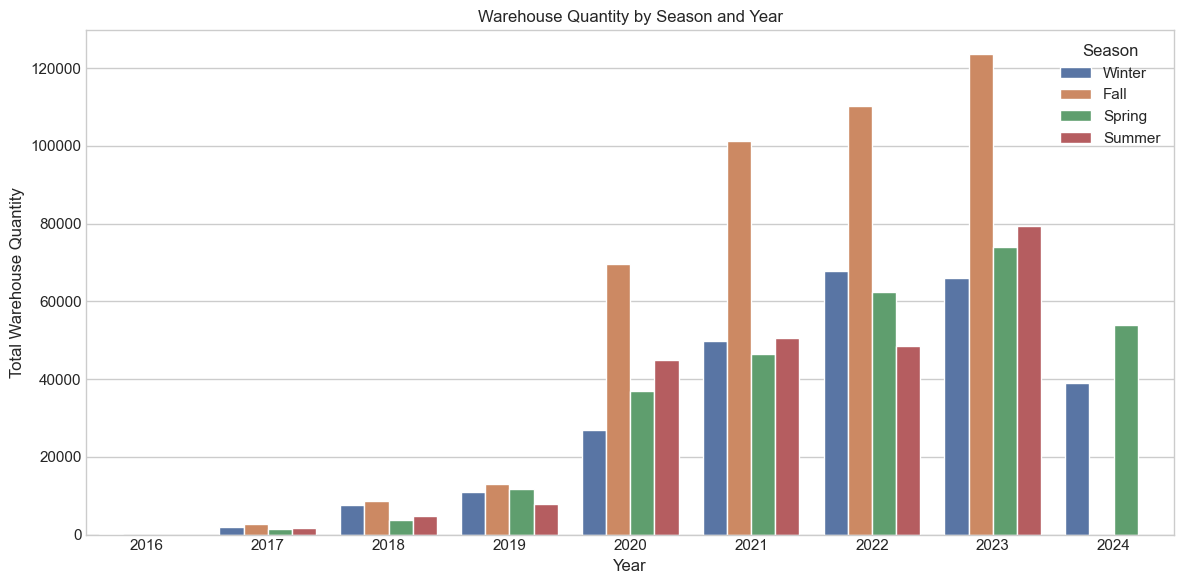

In [138]:
import seaborn as sns
import matplotlib.pyplot as plt

# Group and sum without filtering
season_year_sales = df.groupby(["Season", "Year"])["WareHouseQuantity"].sum().reset_index()

# Sort by Year then Season for proper display
season_year_sales = season_year_sales.sort_values(by=["Year", "Season"])

plt.figure(figsize=(12,6))
sns.barplot(
    data=season_year_sales,
    x="Year",
    y="WareHouseQuantity",
    hue="Season"
)

plt.title("Warehouse Quantity by Season and Year")
plt.ylabel("Total Warehouse Quantity")
plt.xlabel("Year")
plt.legend(title="Season")
plt.tight_layout()
plt.show()


In [139]:
df[df["Year"] == 2024]["Season"].unique()


array(['Winter', 'Spring'], dtype=object)

**`Running total for time series analysis:`**

In [53]:
df = df.sort_values("OrderDate")
df["CumulativeSales"] = df["WareHouseQuantity"].cumsum()


In [54]:
df.head()

,ProductFamily,Order_ID,OrderDate,SKU_Description,WareHouseQuantity,SKU,SKU_category,Channel,ShipToState,ShippingZip,Week,Month,Year,DayOfWeek,HighVolumeSale,IsWeekend,Season,CumulativeSales
0,AIRD,54522457,2016-12-23,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,CA,91403,2016-12-19,12,2016,Friday,0,0,Winter,1.0
1,AIRD,54526264,2016-12-28,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,CA,91326,2016-12-26,12,2016,Wednesday,0,0,Winter,2.0
2,AIRD,54536438,2016-12-30,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,DE,19806,2016-12-26,12,2016,Friday,0,0,Winter,3.0
50,AIRD,54536615,2016-12-31,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,IN,47978,2016-12-26,12,2016,Saturday,0,1,Winter,4.0
49,AIRD,54536604,2016-12-31,Air Doctor AD3000,1.0,90AD01AD01,Unit,WEB_Radial,NY,13850,2016-12-26,12,2016,Saturday,0,1,Winter,5.0


**`Repeat SKU Purchases`**
- Helps identify frequent SKUs:


In [55]:
sku_counts = df["SKU"].value_counts()
df["SKU_RepeatCount"] = df["SKU"].map(sku_counts)


In [56]:
df.head(-1)

,ProductFamily,Order_ID,OrderDate,SKU_Description,WareHouseQuantity,SKU,SKU_category,Channel,ShipToState,ShippingZip,Week,Month,Year,DayOfWeek,HighVolumeSale,IsWeekend,Season,CumulativeSales,SKU_RepeatCount
0,AIRD,54522457,2016-12-23,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,CA,91403,2016-12-19,12,2016,Friday,0,0,Winter,1.0,279511.0
1,AIRD,54526264,2016-12-28,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,CA,91326,2016-12-26,12,2016,Wednesday,0,0,Winter,2.0,279511.0
2,AIRD,54536438,2016-12-30,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,DE,19806,2016-12-26,12,2016,Friday,0,0,Winter,3.0,279511.0
50,AIRD,54536615,2016-12-31,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,IN,47978,2016-12-26,12,2016,Saturday,0,1,Winter,4.0,279511.0
49,AIRD,54536604,2016-12-31,Air Doctor AD3000,1.0,90AD01AD01,Unit,WEB_Radial,NY,13850,2016-12-26,12,2016,Saturday,0,1,Winter,5.0,279511.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1047923,AIRD,282946,2024-04-29,AD3500 1-Year Filter Combo Pack,1.0,10AD350CMPK1,Filter,email,WI,53072,2024-04-29,4,2024,Monday,0,0,Spring,1228279.0,51978.0
1047924,AIRD,282598,2024-04-29,AD3000 1-Year Filter Combo Pack,1.0,10AD02CMPK1,Filter,Main,FL,32129,2024-04-29,4,2024,Monday,0,0,Spring,1228280.0,92214.0
1047925,AIRD,282840,2024-04-29,AD3500 1-Year Filter Combo Pack,2.0,10AD350CMPK1,Filter,email,FL,33701,2024-04-29,4,2024,Monday,0,0,Spring,1228282.0,51978.0
1047926,AIRD,283191,2024-04-29,AD5000 3-year Warranty,1.0,40AD02WC301,Warranty,paid_search,WA,98503,2024-04-29,4,2024,Monday,0,0,Spring,1228283.0,2255.0


### Time Series Decomposition

- **`1. Observed (Top plot)`**
    This is the original WareHouseQuantity data plotted over time.

    You can observe:
    - A general increasing trend over the years.
    - Several sharp spikes, particularly after 2020.
    - The fluctuations become more volatile over time.

- **`2. Trend (Second plot)`**
    This shows the long-term movement of the data.
    It smooths out short-term fluctuations to reveal the underlying direction.

    You can see:
    - A gradual increase from 2017 to 2020.
    - A steeper rise from 2020 to 2022.
    - A slight leveling off or slower growth after 2022.
    This suggests an overall growth in warehouse quantity over the years.

- **`3. Seasonal (Third plot)`**
    - This captures repeating patterns at regular intervals (e.g., yearly or monthly seasonality).
    - In this case, it clearly shows recurring peaks, likely on an annual basis.
    - These consistent spikes could indicate seasonal demand, possibly around **`festivals, holidays, or end-of-year sales (like Diwali, Christmas, Black Friday, etc.).`**

- **`4. Residual (Bottom plot)`**
    This shows what's left over after removing the trend and seasonal components **`i.e., noise or irregular fluctuations.`**
        
    It captures:
    - Unexplained spikes or dips (outliers).
    - Some residuals are large — indicating potential anomalies or unexpected events.
    - Overall, residuals are centered around zero, which is expected in a well-decomposed time series.

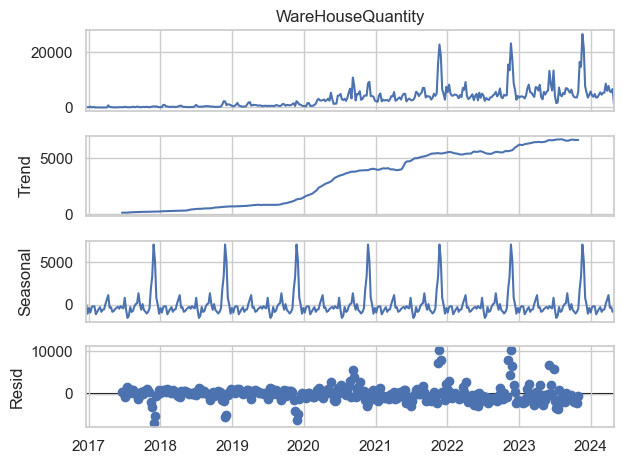

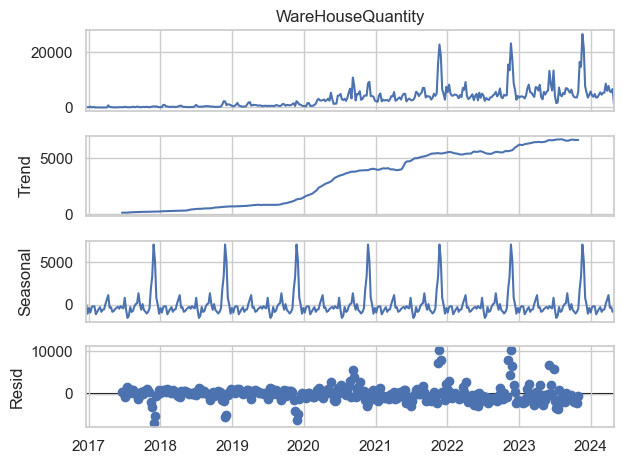

In [57]:
from statsmodels.tsa.seasonal import seasonal_decompose

series = df.groupby('Week')['WareHouseQuantity'].sum()
result = seasonal_decompose(series, model='additive')
result.plot()


### Temporal Patterns and Trends
- `Overall Trend (weekly and monthly)`

<Axes: title={'center': 'Monthly SKU Category Trend'}, xlabel='Month'>

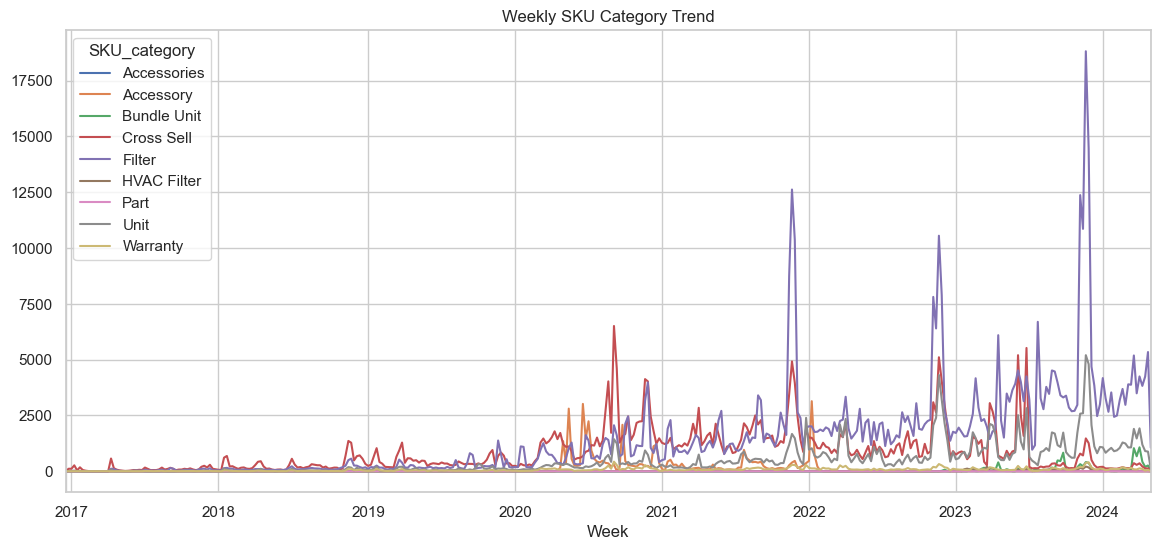

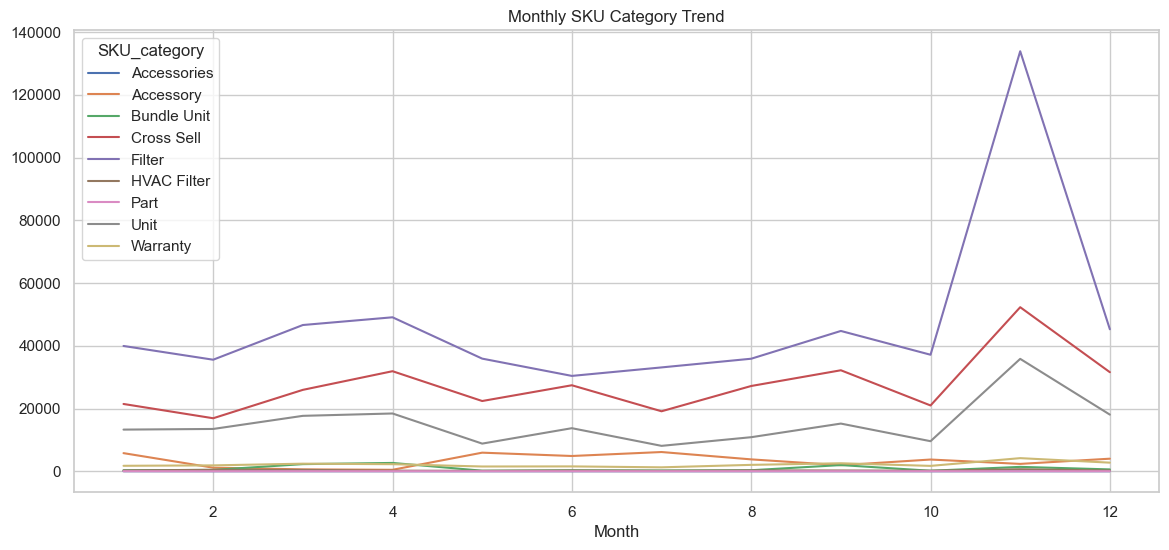

In [58]:
weekly_trend = df.groupby(['Week', 'SKU_category'])['WareHouseQuantity'].sum().unstack().fillna(0)
monthly_trend = df.groupby(['Month', 'SKU_category'])['WareHouseQuantity'].sum().unstack().fillna(0)

weekly_trend.plot(figsize=(14, 6), title='Weekly SKU Category Trend')
monthly_trend.plot(figsize=(14, 6), title='Monthly SKU Category Trend')


- ` State-wise Trend`

In [59]:
import plotly.graph_objects as go
import pandas as pd

# Step 1: Compute total quantity per state and get top 10 states
top_states = df.groupby('ShipToState')['WareHouseQuantity'].sum().nlargest(10).index

# Step 2: Create the pivot table for weekly trend
state_trend = df.groupby(['Week', 'ShipToState'])['WareHouseQuantity'].sum().unstack().fillna(0)

# Step 3: Filter columns to include only top 10 states
state_trend_top10 = state_trend[top_states]

# Step 4: Create Plotly line chart with formatted hover and x-axis
fig = go.Figure()

# Custom color palette
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

# Add one smooth line per state
for i, state in enumerate(state_trend_top10.columns):
    fig.add_trace(go.Scatter(
        x=state_trend_top10.index,
        y=state_trend_top10[state],
        mode='lines',
        name=state,
        line=dict(shape='spline', color=colors[i % len(colors)], width=2.5),
        fill='tozeroy',
        hovertemplate=f"<b>{state}</b><br>Week Start: %{{x|%Y-%m-%d}}<br>Quantity: %{{y:,}}<extra></extra>"
    ))

# Format x-axis to show full dates
fig.update_xaxes(
    title='Week',
    tickformat="%Y-%m-%d",       # e.g., "2024-07-01"
    tickangle=45,
    showgrid=True
)

# Customize layout
fig.update_layout(
    title='<b>Weekly Warehouse Quantity Trend — Top 10 States</b>',
    title_font_size=22,
    xaxis_title='Week Start Date',
    yaxis_title='Warehouse Quantity',
    legend_title='State',
    template='plotly_white',
    font=dict(family='Segoe UI, sans-serif', size=14),
    width=1100,
    height=600,
    hovermode='x unified',
    plot_bgcolor='rgba(245, 247, 251, 1)',
    paper_bgcolor='rgba(240, 240, 240, 1)',
    margin=dict(t=60, l=60, r=30, b=90)  # more bottom space for angled ticks
)

fig.show()


### Geographical Patterns
- **`State-wise Distribution of Total Warehouse Inventory`**

C:\Users\Nilam Wadhavane\AppData\Local\Temp\ipykernel_24112\3091767652.py:11: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




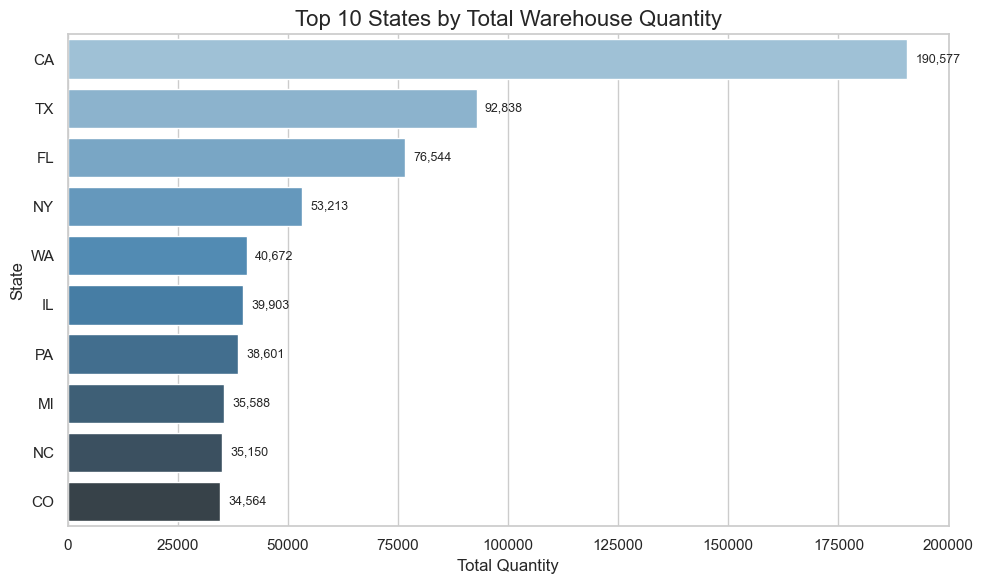

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group, sort, and select top 10 states
state_quantity = df.groupby('ShipToState')['WareHouseQuantity'].sum().sort_values(ascending=False).head(10)

# Set figure size
plt.figure(figsize=(10, 6))

# Create the barplot
ax = sns.barplot(x=state_quantity.values, y=state_quantity.index, palette='Blues_d')

# Title and axis labels
plt.title("Top 10 States by Total Warehouse Quantity", fontsize=16)
plt.xlabel("Total Quantity", fontsize=12)
plt.ylabel("State", fontsize=12)

# Add text labels on bars
offset = state_quantity.max() * 0.01  # use .max() as a method
for i, (value, state) in enumerate(zip(state_quantity.values, state_quantity.index)):
    ax.text(value + offset, i, f'{int(value):,}', va='center', fontsize=9)

# Improve layout
plt.tight_layout()

# Show the plot
plt.show()


- **`U.S. State-Level Warehouse Demand Heatmap`**
1) **Choropleth Map:** A thematic map where areas are shaded in proportion to the value of a variable (in this case, WareHouseQuantity).

2) **Heatmap (in this context):** Refers to the varying intensity of color to represent demand.

In [61]:
import plotly.express as px

state_qty = df.groupby('ShipToState')['WareHouseQuantity'].sum().reset_index()
fig = px.choropleth(state_qty,
                    locations='ShipToState',
                    locationmode="USA-states",
                    color='WareHouseQuantity',
                    scope="usa",
                    title='Warehouse Demand Distribution Heatmap Across U.S. States')
fig.show()


###  SKU/Product-Level Analysis
- **`Top SKUs`**

<Axes: title={'center': 'Top 10 SKUs by Demand'}, ylabel='SKU_Description'>

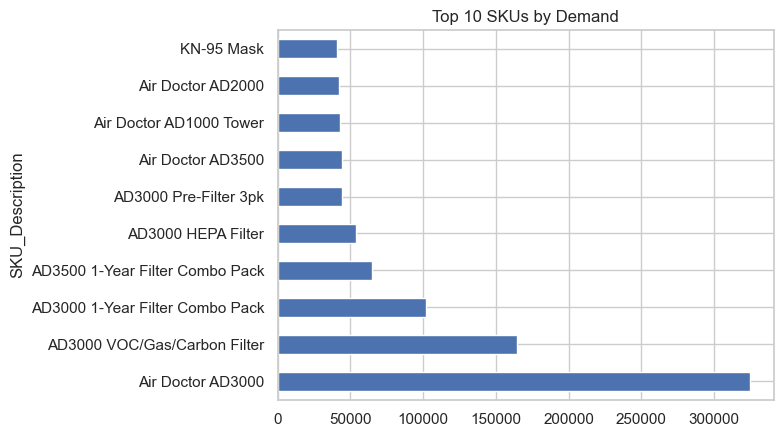

In [62]:
top_skus = df.groupby('SKU_Description')['WareHouseQuantity'].sum().sort_values(ascending=False).head(10)
top_skus.plot(kind='barh', title="Top 10 SKUs by Demand")


### Correlation and Dependency Analysis

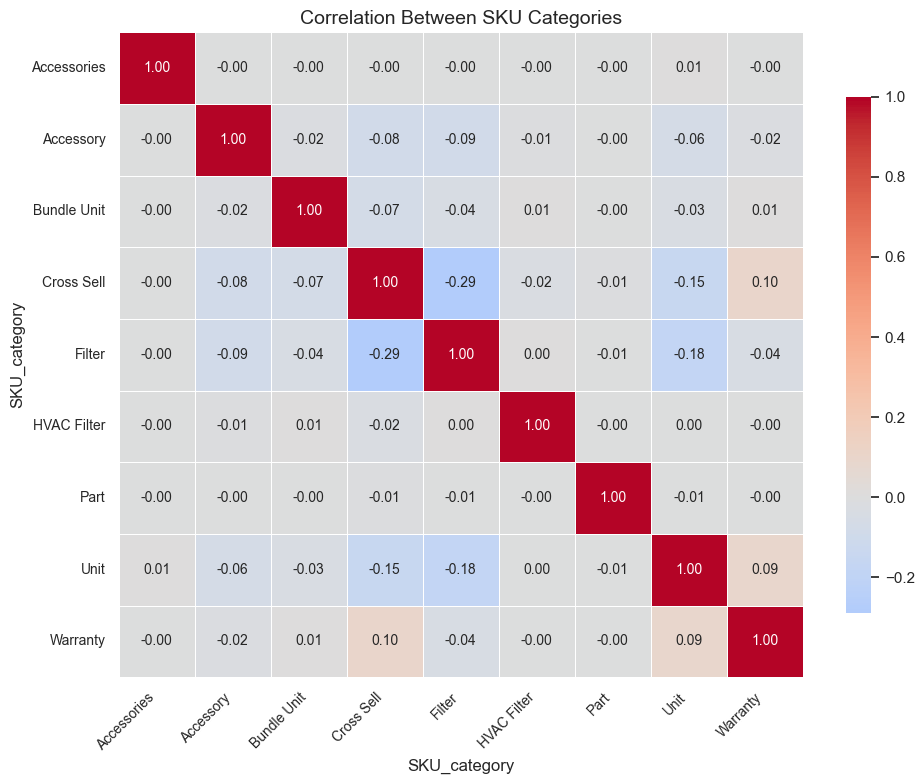

In [63]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# STEP 1: Pivot to get a matrix where each row is an order and columns are SKU categories
sku_corr = df.pivot_table(
    index='Order_ID',
    columns='SKU_category',
    values='WareHouseQuantity',
    aggfunc='sum'
).fillna(0)

# STEP 2: Compute the correlation matrix
corr_matrix = sku_corr.corr()

# STEP 3: Plotting the heatmap
plt.figure(figsize=(10, 8))  # Set figure size for better readability
sns.set(style="whitegrid")

ax = sns.heatmap(
    corr_matrix,
    annot=True,         # Show correlation values
    fmt=".2f",          # Two decimal places
    cmap="coolwarm",    # Color palette
    center=0,           # Center colormap at 0
    linewidths=0.5,     # Line between cells
    cbar_kws={"shrink": 0.8},  # Shrink colorbar
    annot_kws={"size": 10}     # Annotation text size
)

plt.title("Correlation Between SKU Categories", fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()


### Weekly Sales Trend

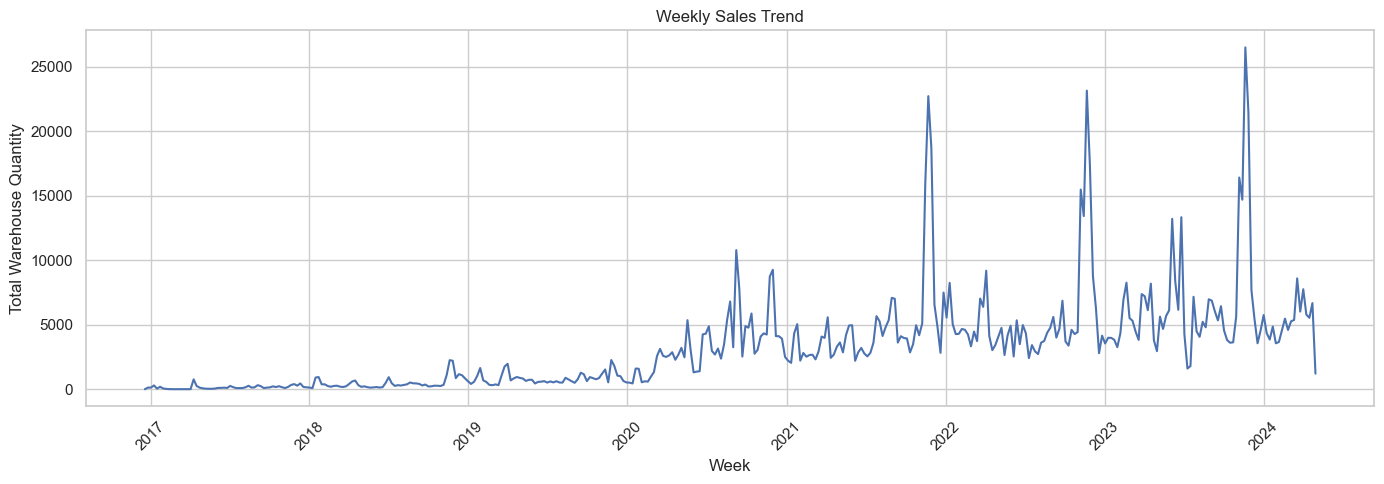

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

weekly_trend = df.groupby('Week')['WareHouseQuantity'].sum().reset_index()

plt.figure(figsize=(14, 5))
sns.lineplot(data=weekly_trend, x='Week', y='WareHouseQuantity')
plt.title("Weekly Sales Trend")
plt.xlabel("Week")
plt.ylabel("Total Warehouse Quantity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Top 10 SKUs

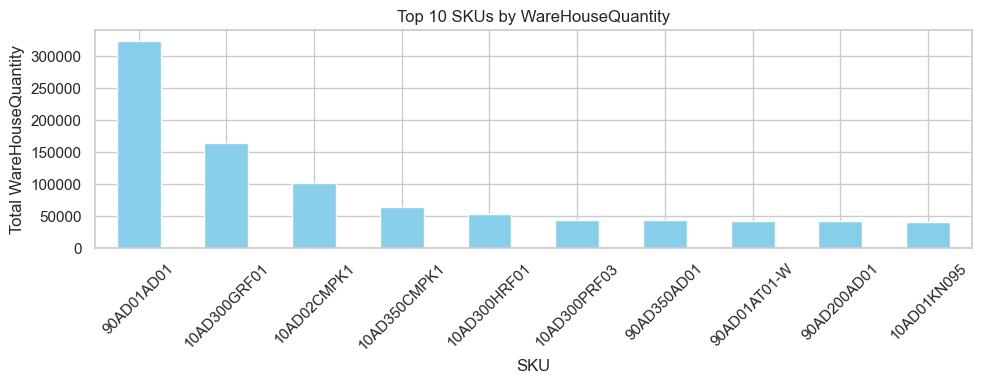

In [65]:
top_skus = df.groupby('SKU')['WareHouseQuantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 4))
top_skus.plot(kind='bar', color='skyblue')
plt.title("Top 10 SKUs by WareHouseQuantity")
plt.ylabel("Total WareHouseQuantity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Range Of SKUs

In [66]:
def print_date_ranges(df, sku_list=None):
    """
    Prints the overall dataset date range and individual date ranges for specified SKUs.

    Parameters:
    df (pd.DataFrame): DataFrame containing at least 'OrderDate' and 'SKU' columns.
    sku_list (list, optional): List of SKU strings to check date ranges for.
    """
    print("Full dataset date range:", df['OrderDate'].min(), "to", df['OrderDate'].max())
    
    if sku_list:
        for sku in sku_list:
            df_sku_check = df[df['SKU'] == sku]
            if not df_sku_check.empty:
                print(f"Selected SKU date range {sku}:", df_sku_check['OrderDate'].min(), "to", df_sku_check['OrderDate'].max())
                # print(f"Total weekly data points for this SKU: {df_sku_check.shape[0]}")
            else:
                print(f"No data found for SKU: {sku}")
                


In [67]:
sku_list = ['90AD350AD01', '90AD200AD01', '90AD01AT01-W', '90AD02AD01', '90AD550AD01']
print_date_ranges(df, sku_list)


Full dataset date range: 2016-12-23 00:00:00 to 2024-04-29 00:00:00
Selected SKU date range 90AD350AD01: 2022-09-15 00:00:00 to 2024-04-29 00:00:00
Selected SKU date range 90AD200AD01: 2022-06-04 00:00:00 to 2024-04-29 00:00:00
Selected SKU date range 90AD01AT01-W: 2019-08-16 00:00:00 to 2024-04-29 00:00:00
Selected SKU date range 90AD02AD01: 2021-05-25 00:00:00 to 2023-06-30 00:00:00
Selected SKU date range 90AD550AD01: 2022-09-15 00:00:00 to 2024-04-29 00:00:00


### SKU Activity Timeline (Active vs Inactive) For all SKUs

In [70]:
import pandas as pd
import plotly.express as px

# Ensure OrderDate is datetime
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

# Get latest date
latest_date = df['OrderDate'].max()

# Thresholds
threshold_days = 90       # Inactivity threshold (e.g., used in last 90 days)
min_active_days = 365     # Minimum activity period for forecasting

# Step 1: Get SKU activity ranges
sku_ranges = df.groupby('SKU')['OrderDate'].agg(['min', 'max']).reset_index()
sku_ranges.columns = ['SKU', 'StartDate', 'EndDate']

# Step 2: Determine if SKUs are active (used in last N days)
sku_ranges['DaysSinceLastUse'] = (latest_date - sku_ranges['EndDate']).dt.days
sku_ranges['IsActive'] = sku_ranges['DaysSinceLastUse'] <= threshold_days

# Step 3: Determine if SKUs are forecastable (active for ≥ 1 year)
sku_ranges['ActiveDurationDays'] = (sku_ranges['EndDate'] - sku_ranges['StartDate']).dt.days
sku_ranges['IsForecastable'] = (sku_ranges['IsActive']) & (sku_ranges['ActiveDurationDays'] >= min_active_days)

# Step 4: Assign status label
def classify(row):
    if row['IsForecastable']:
        return 'Forecastable'
    elif row['IsActive']:
        return 'Active but Not Forecastable'
    else:
        return 'Inactive'

sku_ranges['Status'] = sku_ranges.apply(classify, axis=1)

# Step 5: Add formatted date range
sku_ranges['DateRange'] = sku_ranges['StartDate'].dt.strftime('%Y-%m-%d') + " → " + sku_ranges['EndDate'].dt.strftime('%Y-%m-%d')

# Step 6: Count SKUs by status
status_counts = sku_ranges['Status'].value_counts()
total_skus = len(sku_ranges)
forecastable_count = status_counts.get('Forecastable', 0)
active_not_forecastable_count = status_counts.get('Active but Not Forecastable', 0)
inactive_count = status_counts.get('Inactive', 0)

# Print summary
print("\nSKU Forecasting Eligibility Summary")
print(f"Total SKUs                        : {total_skus}")
print(f"Forecastable SKUs                 : {forecastable_count}")
print(f"Active but Not Forecastable SKUs : {active_not_forecastable_count}")
print(f"Inactive SKUs                     : {inactive_count}")

# Define color map
color_map = {
    'Forecastable': 'green',
    'Active but Not Forecastable': 'orange',
    'Inactive': 'red'
}

# Plot the SKU activity timeline
fig = px.timeline(
    sku_ranges,
    x_start="StartDate",
    x_end="EndDate",
    y="SKU",
    color="Status",
    text="DateRange",
    color_discrete_map=color_map,
    title=(
        f"SKU Activity Timeline | "
        f"Total: {total_skus} | Forecastable: {forecastable_count} | "
        f"Active but Not Forecastable:  {active_not_forecastable_count} | "
        f"Inactive: {inactive_count}"
    )
)

fig.update_yaxes(autorange="reversed")  # Reverse Y-axis for Gantt style
fig.update_traces(textposition='inside', insidetextanchor='start')

fig.update_layout(
    xaxis_title="Date Range",
    yaxis_title="SKU",
    legend_title="SKU Status",
    xaxis=dict(
        showgrid=True,
        gridcolor='LightGray',
        tickformat='%Y',
        dtick="M12"
    ),
    height=max(600, 20 * len(sku_ranges)),
    margin=dict(l=120, r=20, t=60, b=40)
)

fig.show()



SKU Forecasting Eligibility Summary
Total SKUs                        : 93
Forecastable SKUs                 : 41
Active but Not Forecastable SKUs : 29
Inactive SKUs                     : 23


### Which SKUs are forecastable?
- This bar chart shows the top 10 SKUs based on total warehouse quantity. Each SKU bar is color-coded by its forecastability status:

    🟩 **`Green – Forecastable`**
    🟧 **`Orange – Not Forecastable`**
    🟥 **`Red – Inactive`**

- The vertical bars represent total warehouse quantity, and each SKU is annotated with its start and end date, which determines its status.

    **`Forecastable: Example`**
    - SKU: 10AD300GRF01
    - Start Date: 2017-02-01
    - End Date: 2024-04-25
    - Status: Forecastable

    Reason: This SKU is still active and has a long history of sales data (more than 1 year), making it ideal for building a reliable forecast model.

    **`Not Forecastable: Example`**
    - SKU: 10AD350CMPK1
    - Start Date: 2023-06-28
    - End Date: 2024-04-29
    - Status: Not Forecastable
    
    Reason: This SKU is active but has less than 1 year of historical sales data, which is not sufficient to detect seasonality or trends reliably.

    **`Inactive: Example`**
    - SKU: 90AD01AD01
    - Start Date: 2016-12-23
    - End Date: 2023-07-01
    - Status: Inactive

    Reason: Despite having a rich historical dataset, the SKU has not been active for more than 90 days before the latest order date (2024-04-29). Thus, it’s considered inactive and excluded from forecasting.

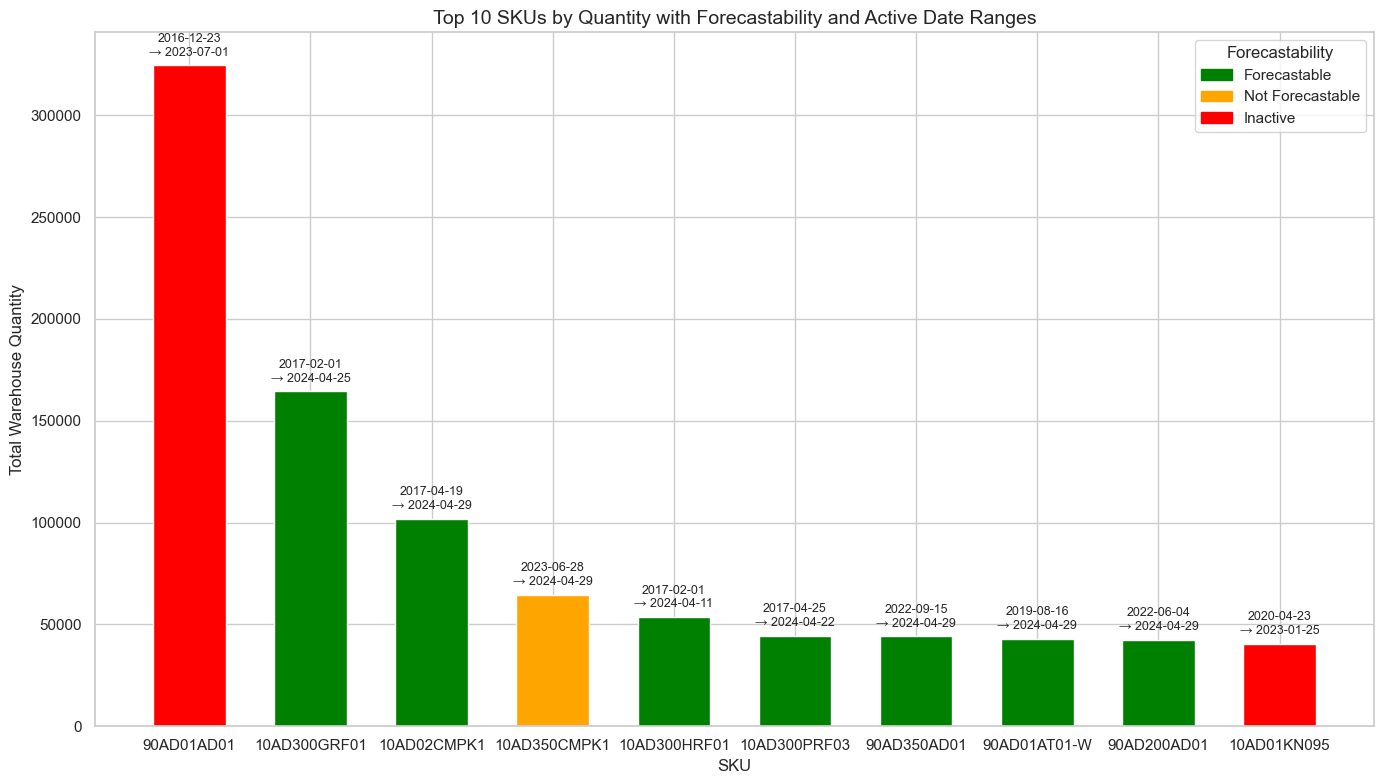


Full Forecastability Table:

Summary Statistics:
Total SKUs             : 93
Forecastable SKUs      : 41
Not Forecastable SKUs  : 29
Inactive SKUs          : 23


,SKU,StartDate,EndDate,TotalOrders,TotalQuantity,ActiveDays,Status,Forecastability,Color
0,10AD01CV01,2023-09-08,2024-01-06,2,2.0,120,Inactive,Inactive,red
1,10AD01FNA02,2023-01-25,2024-03-07,676,833.0,407,Active,Forecastable,green
2,10AD01FNB02,2023-01-25,2024-04-29,630,789.0,460,Active,Forecastable,green
3,10AD01FNC02,2023-01-24,2024-04-04,659,828.0,436,Active,Forecastable,green
4,10AD01FND02,2023-01-25,2024-04-28,142,160.0,459,Active,Forecastable,green
...,...,...,...,...,...,...,...,...,...
88,90IL01BJG01,2018-11-09,2019-06-05,544,591.0,208,Inactive,Inactive,red
89,90ST01ST01,2021-04-22,2023-12-22,682,704.0,974,Inactive,Inactive,red
90,ATNI,2019-11-25,2022-10-14,1566,1703.0,1054,Inactive,Inactive,red
91,BOGUS SKU,2017-07-26,2022-04-06,29,30.0,1715,Inactive,Inactive,red


In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Get the latest order date
latest_date = df["OrderDate"].max()

# Process SKU-level metrics
sku_activity = df.groupby("SKU").agg(
    StartDate=("OrderDate", "min"),
    EndDate=("OrderDate", "max"),
    TotalOrders=("Order_ID", "count"),
    TotalQuantity=("WareHouseQuantity", "sum")
).reset_index()

sku_activity["ActiveDays"] = (sku_activity["EndDate"] - sku_activity["StartDate"]).dt.days
sku_activity["Status"] = sku_activity["EndDate"].apply(
    lambda x: "Inactive" if (latest_date - x).days > 90 else "Active"
)
sku_activity["Forecastability"] = sku_activity.apply(
    lambda row: "Forecastable" if row["Status"] == "Active" and row["ActiveDays"] >= 365 else
                ("Not Forecastable" if row["Status"] == "Active" else "Inactive"),
    axis=1
)

# Map colors
color_map = {"Forecastable": "green", "Not Forecastable": "orange", "Inactive": "red"}
sku_activity["Color"] = sku_activity["Forecastability"].map(color_map)

# Get top 10 SKUs by total quantity
top10 = sku_activity.sort_values("TotalQuantity", ascending=False).head(10).copy()

# Plot setup
fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.bar(top10["SKU"], top10["TotalQuantity"], color=top10["Color"], width=0.6)

# Title and labels
ax.set_title("Top 10 SKUs by Quantity with Forecastability and Active Date Ranges", fontsize=14)
ax.set_xlabel("SKU", fontsize=12)
ax.set_ylabel("Total Warehouse Quantity", fontsize=12)
ax.tick_params(axis='x', rotation=0)

# Add annotations with date ranges
for bar, (_, row) in zip(bars, top10.iterrows()):
    height = bar.get_height()
    start = row['StartDate'].strftime("%Y-%m-%d")
    end = row['EndDate'].strftime("%Y-%m-%d")
    text = f"{start}\n→ {end}"
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01 * top10["TotalQuantity"].max(),
        text,
        ha='center',
        va='bottom',
        fontsize=9
    )

# Add legend
legend_handles = [mpatches.Patch(color=color_map[key], label=key) for key in color_map]
ax.legend(handles=legend_handles, title="Forecastability")

plt.tight_layout()
plt.savefig("top10_sku_forecastability_cleaned.png", dpi=300)  # If you want to save the figure uncomment this line
plt.show()

# -----------------------------
# Summary Table and Statistics
# -----------------------------

# Display the entire SKU forecastability table
print("\nFull Forecastability Table:")
# print(sku_activity[["SKU", "StartDate", "EndDate", "ActiveDays", "TotalQuantity", "Forecastability"]])

# Count statistics
total_skus = len(sku_activity)
forecastable_count = (sku_activity["Forecastability"] == "Forecastable").sum()
not_forecastable_count = (sku_activity["Forecastability"] == "Not Forecastable").sum()
inactive_count = (sku_activity["Forecastability"] == "Inactive").sum()

print("\nSummary Statistics:")
print(f"Total SKUs             : {total_skus}")
print(f"Forecastable SKUs      : {forecastable_count}")
print(f"Not Forecastable SKUs  : {not_forecastable_count}")
print(f"Inactive SKUs          : {inactive_count}")

# Optional: Save full table as CSV
# sku_activity.to_csv("sku_forecastability_summary.csv", index=False)
sku_activity


### Can we forecast at channel and shipping state level?

In [157]:
df.head()

,ProductFamily,Order_ID,OrderDate,SKU_Description,WareHouseQuantity,SKU,SKU_category,Channel,ShipToState,ShippingZip,...,Month,Year,DayOfWeek,HighVolumeSale,IsWeekend,Season,CumulativeSales,SKU_RepeatCount,DayName,YearWeek
0,AIRD,54522457,2016-12-23,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,CA,91403,...,12,2016,Friday,0,0,Winter,1.0,279511.0,Friday,2016-51
1,AIRD,54526264,2016-12-28,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,CA,91326,...,12,2016,Wednesday,0,0,Winter,2.0,279511.0,Wednesday,2016-52
2,AIRD,54536438,2016-12-30,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,DE,19806,...,12,2016,Friday,0,0,Winter,3.0,279511.0,Friday,2016-52
50,AIRD,54536615,2016-12-31,Air Doctor AD3000,1.0,90AD01AD01,Cross Sell,WEB_Radial,IN,47978,...,12,2016,Saturday,0,1,Winter,4.0,279511.0,Saturday,2016-52
49,AIRD,54536604,2016-12-31,Air Doctor AD3000,1.0,90AD01AD01,Unit,WEB_Radial,NY,13850,...,12,2016,Saturday,0,1,Winter,5.0,279511.0,Saturday,2016-52


In [158]:
# Aggregate daily sales by Channel
daily_channel_sales = (
    df.groupby(['OrderDate', 'Channel'])['WareHouseQuantity']
      .sum()
      .reset_index()
)

# Count number of days with sales (sales_qty > 0) per Channel
coverage = (
    daily_channel_sales.groupby('Channel')
                       .apply(lambda x: (x['WareHouseQuantity'] > 0).sum())
                       .reset_index(name='days_with_sales')
)

# Create descriptive forecastability column
coverage['forecastable'] = coverage['days_with_sales'].apply(lambda x: 'Forecastable' if x > 365 else 'Not Forecastable')

print(coverage.sort_values('days_with_sales', ascending=False))

forecastable_channels = coverage[coverage['forecastable'] == 'Forecastable']['Channel'].tolist()
print("\nChannels forecastable based on >365 days sales data:")
print(forecastable_channels)


                Channel  days_with_sales      forecastable
20           WEB_Radial             2333      Forecastable
19         UDSOE_Radial             1897      Forecastable
1     DIG_INFLCR_Radial              813      Forecastable
4      DIG_PDSCL_Radial              805      Forecastable
12           SEM_Radial              764      Forecastable
10                 Main              609      Forecastable
26                email              552      Forecastable
28       organic_social              552      Forecastable
31          paid_social              470      Forecastable
7          EMAIL_Radial              400      Forecastable
21      affiliate_email              369      Forecastable
5        Digital_Radial              343  Not Forecastable
23     affiliate_social              338  Not Forecastable
3      DIG_OTHER_Radial              325  Not Forecastable
22  affiliate_publisher              288  Not Forecastable
30          paid_search              279  Not Forecastab

C:\Users\Nilam Wadhavane\AppData\Local\Temp\ipykernel_24112\1763293967.py:11: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



Yes, we can forecast at the channel level for channels that have more than 365 days of sales data.

The forecastable channels are:
- WEB_Radial, UDSOE_Radial, DIG_INFLCR_Radial, DIG_PDSCL_Radial, SEM_Radial, Main, email, organic_social, 	paid_social, EMAIL_Radial, affiliate_email.

These channels have sufficient historical sales data to build reliable forecasts.


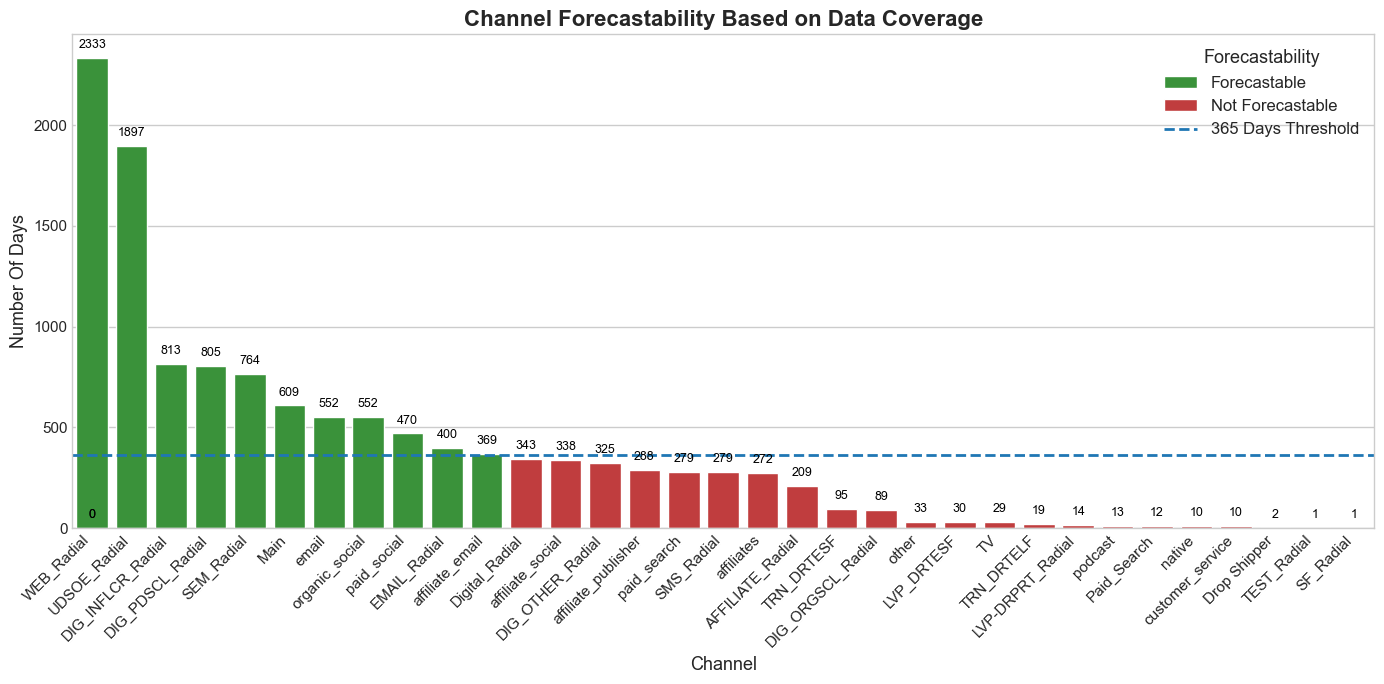

In [168]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Map boolean to string for better legend labels
coverage['Forecastability'] = coverage['forecastable'].map({True: 'Forecastable', False: 'Not Forecastable'})

plt.figure(figsize=(14,7))
sns.set_style("whitegrid")

# Sort data for better visual hierarchy
coverage_sorted = coverage.sort_values('days_with_sales', ascending=False)

# Define custom palette
palette = {'Forecastable': '#2ca02c', 'Not Forecastable': '#d62728'}  # Green and Red

barplot = sns.barplot(
    data=coverage_sorted,
    x='Channel',
    y='days_with_sales',
    hue='forecastable',
    palette=palette,
    dodge=False
)

# Add horizontal line at 365 days threshold
plt.axhline(365, color='#1f77b4', linestyle='--', linewidth=2, label='365 Days Threshold')

# Add data labels on top of bars
for p in barplot.patches:
    height = p.get_height()
    barplot.annotate(f'{int(height)}',
                     (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='bottom',
                     fontsize=9, color='black',
                     xytext=(0, 5),
                     textcoords='offset points')

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.xlabel('Channel', fontsize=13)
plt.ylabel('Number Of Days', fontsize=13)
plt.title('Channel Forecastability Based on Data Coverage', fontsize=16, weight='bold')

plt.legend(title='Forecastability', fontsize=12, title_fontsize=13, loc='upper right')
plt.tight_layout()
plt.show()


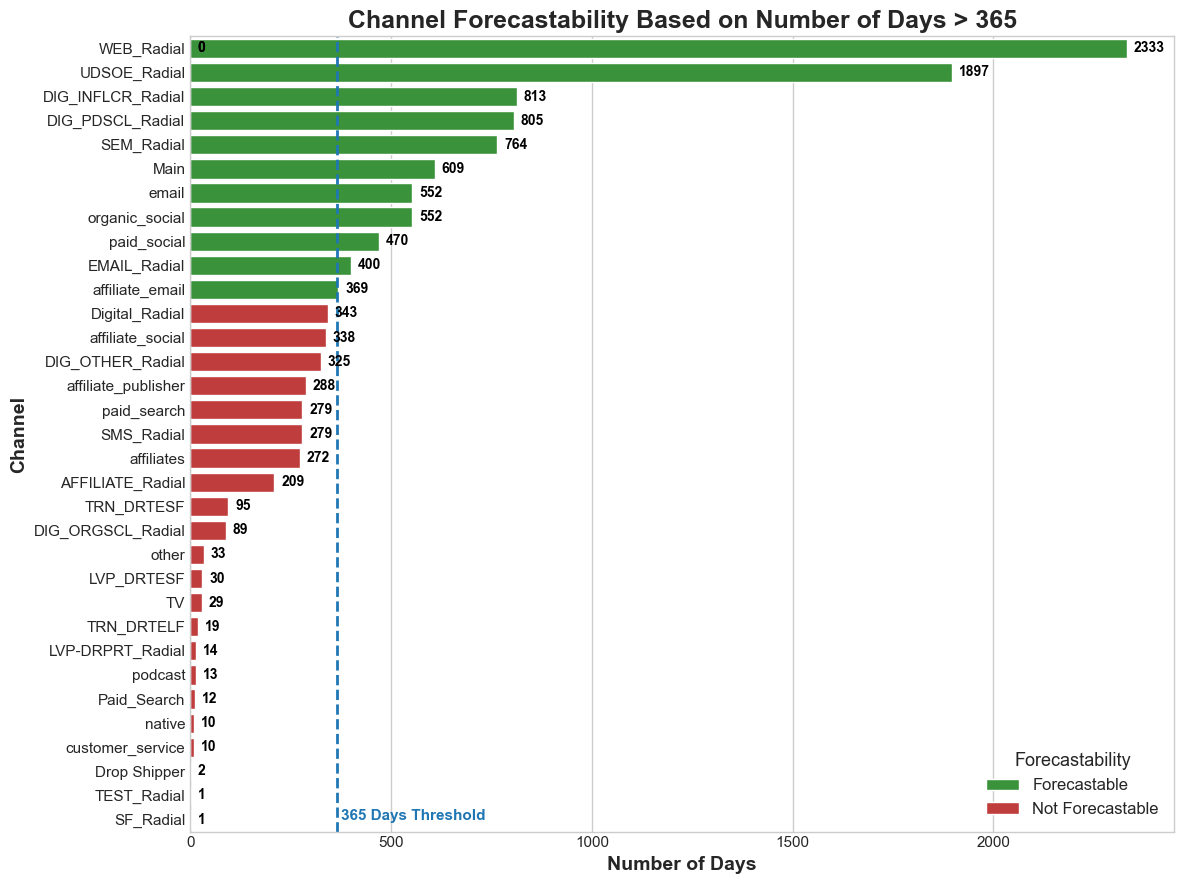

In [165]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data sorted by days_with_sales
coverage_sorted = coverage.sort_values('days_with_sales', ascending=False)  # ascending for horizontal barplot

# Map forecastability colors
palette = {'Forecastable': '#2ca02c', 'Not Forecastable': '#d62728'}  # Green & Red

plt.figure(figsize=(12, 9))
sns.set_style("whitegrid")

barplot = sns.barplot(
    data=coverage_sorted,
    y='Channel',
    x='days_with_sales',
    hue='forecastable',
    palette=palette,
    dodge=False
)

# Add data labels on bars
for p in barplot.patches:
    width = p.get_width()
    barplot.annotate(
        f'{int(width)}',
        (width, p.get_y() + p.get_height() / 2),
        xytext=(5, 0),
        textcoords='offset points',
        ha='left',
        va='center',
        fontsize=10,
        color='black',
        weight='bold'
    )

# Add vertical threshold line for 365 days
plt.axvline(365, color='#1f77b4', linestyle='--', linewidth=2)
plt.text(365 + 10, len(coverage_sorted) - 1, '365 Days Threshold', color='#1f77b4', fontsize=11, weight='semibold')

plt.xlabel('Number of Days', fontsize=14, weight='bold')
plt.ylabel('Channel', fontsize=14, weight='bold')
plt.title('Channel Forecastability Based on Number of Days > 365', fontsize=18, weight='bold')
plt.legend(title='Forecastability', fontsize=12, title_fontsize=13, loc='lower right')

plt.tight_layout()
plt.show()


### Can We Forecast at the Shipping State Level?

- Yes, forecasting is possible for several shipping states that have more than 365 days of sales data. This means these states have enough historical sales records to build reliable forecasting models capturing trends and seasonality.

- However, many states have less than 365 days of sales, making them less reliable for direct forecasting. These low-data states might require data aggregation (weekly/monthly), grouping similar states, or alternative forecasting techniques.

- Overall, the forecastability at the state level is more fragmented compared to channels, with fewer states having consistently rich data.

- Focus initial forecasting efforts on the top forecastable states with highest sales coverage to maximize model accuracy and business impact.

In [185]:
# Aggregate daily sales by ShipToState
daily_state_sales = (
    df.groupby(['OrderDate', 'ShipToState'])['WareHouseQuantity']
      .sum()
      .reset_index()
)

# Count number of days with sales (sales_qty > 0) per ShipToState
state_coverage = (
    daily_state_sales.groupby('ShipToState')
                     .apply(lambda x: (x['WareHouseQuantity'] > 0).sum())
                     .reset_index(name='days_with_sales')
)

# Create descriptive forecastability column
state_coverage['forecastable'] = state_coverage['days_with_sales'].apply(
    lambda x: 'Forecastable' if x > 365 else 'Not Forecastable'
)

# Print sorted data coverage by state
print(state_coverage.sort_values('days_with_sales', ascending=False))

# Get list of forecastable states
forecastable_states = state_coverage[state_coverage['forecastable'] == 'Forecastable']['ShipToState'].tolist()
print("\nStates forecastability based on data coverage:")
print(forecastable_states)

# Count how many states are forecastable
num_forecastable_states = len(forecastable_states)
print(f"\nNumber of states forecastable based on data coverage: {num_forecastable_states}")


   ShipToState  days_with_sales      forecastable
12          CA             2572      Forecastable
81          TX             2427      Forecastable
19          FL             2415      Forecastable
58          NY             2340      Forecastable
88          WA             2216      Forecastable
..         ...              ...               ...
72      Rincón                1  Not Forecastable
86     Vieques                1  Not Forecastable
92  Washington                1  Not Forecastable
95        guam                1  Not Forecastable
96          nv                1  Not Forecastable

[98 rows x 3 columns]

States forecastability based on data coverage:
['AB', 'AK', 'AL', 'AR', 'AZ', 'BC', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MB', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'ON', 'OR', 'PA', 'QC', 'RI', 'SC', 'SD', 'SK', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA', 'WI'

C:\Users\Nilam Wadhavane\AppData\Local\Temp\ipykernel_24112\4147301880.py:11: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



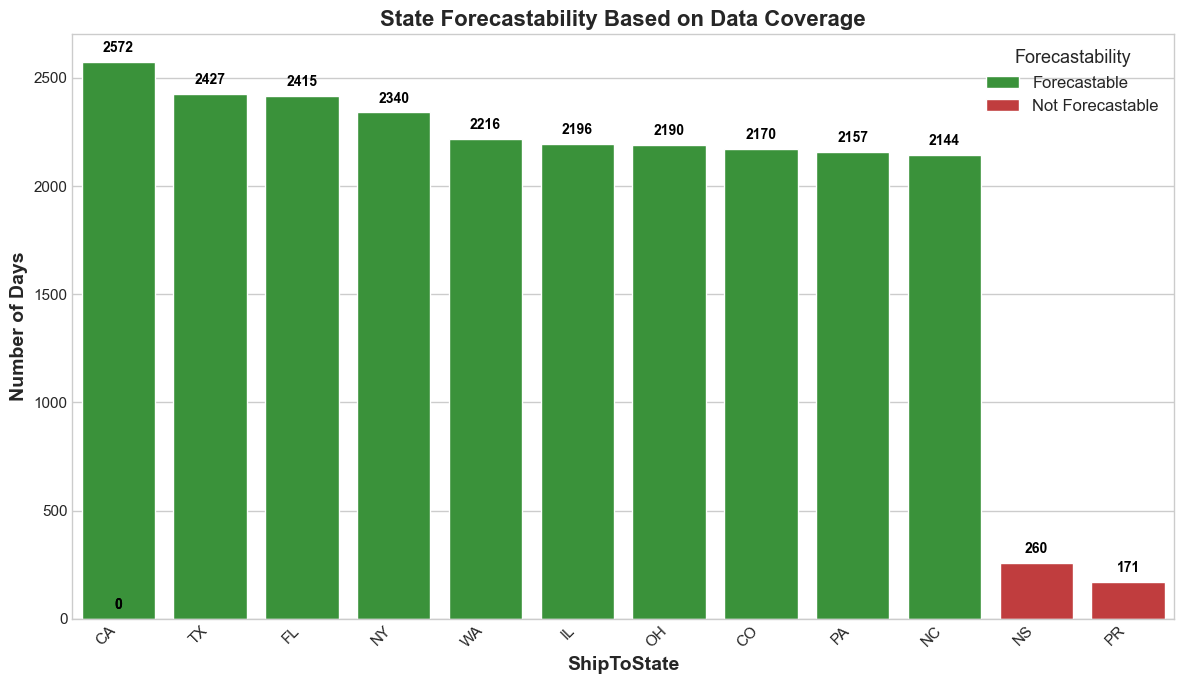

In [192]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get top 10 forecastable states
top10_forecastable = state_coverage[state_coverage['forecastable'] == 'Forecastable'] \
                     .sort_values('days_with_sales', ascending=False).head(10)

# Get top 2 not forecastable states
top2_not_forecastable = state_coverage[state_coverage['forecastable'] == 'Not Forecastable'] \
                        .sort_values('days_with_sales', ascending=False).head(2)

# Combine into one DataFrame
combined_states = pd.concat([top10_forecastable, top2_not_forecastable])

# Sort by days_with_sales for better bar order
combined_states = combined_states.sort_values('days_with_sales', ascending=False)

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

palette = {'Forecastable': '#2ca02c', 'Not Forecastable': '#d62728'}

barplot = sns.barplot(
    data=combined_states,
    x='ShipToState',
    y='days_with_sales',
    hue='forecastable',
    palette=palette,
    dodge=False
)

# Add data labels on top of bars
for p in barplot.patches:
    height = p.get_height()
    barplot.annotate(
        f'{int(height)}',
        (p.get_x() + p.get_width() / 2, height),
        ha='center',
        va='bottom',
        fontsize=10,
        color='black',
        weight='bold',
        xytext=(0, 5),
        textcoords='offset points'
    )

plt.ylabel('Number of Days', fontsize=14, weight='bold')
plt.xlabel('ShipToState', fontsize=14, weight='bold')
plt.title('State Forecastability Based on Data Coverage', fontsize=16, weight='bold')
plt.xticks(rotation=45, ha='right')

plt.legend(title='Forecastability', fontsize=12, title_fontsize=13, loc='upper right')

plt.tight_layout()
plt.show()


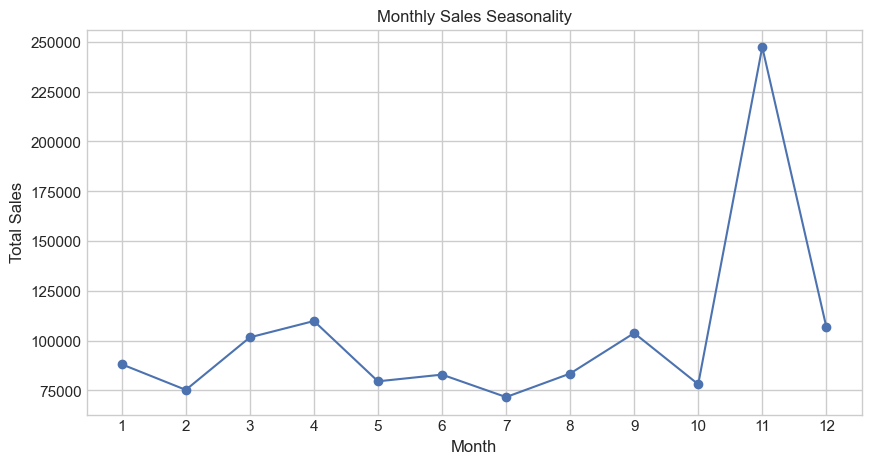

In [193]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert OrderDate to datetime if not already
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

# Extract month and year
df['Month'] = df['OrderDate'].dt.month

# Aggregate average sales by month
monthly_sales = df.groupby('Month')['WareHouseQuantity'].sum()

# Plot
plt.figure(figsize=(10,5))
monthly_sales.plot(marker='o')
plt.title('Monthly Sales Seasonality')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(range(1,13))
plt.grid(True)
plt.show()


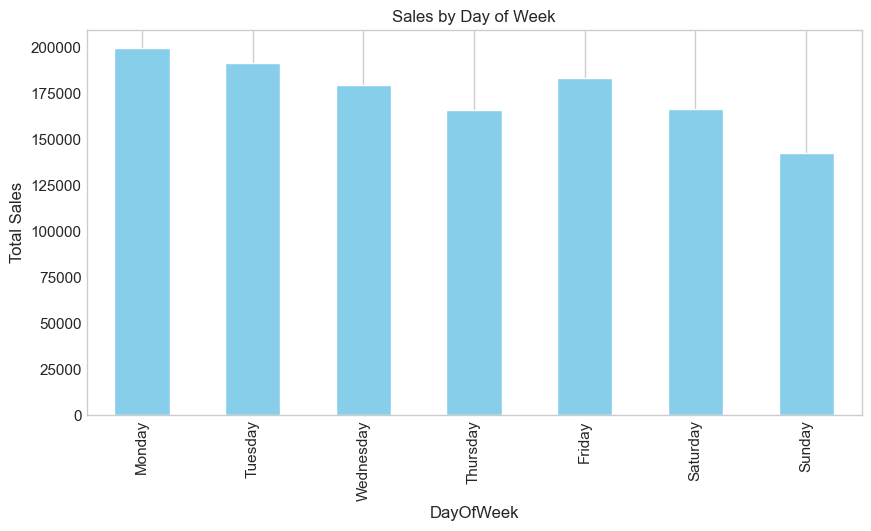

In [194]:
df['DayOfWeek'] = df['OrderDate'].dt.day_name()

dow_sales = df.groupby('DayOfWeek')['WareHouseQuantity'].sum()

# Order days properly
ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_sales = dow_sales.reindex(ordered_days)

plt.figure(figsize=(10,5))
dow_sales.plot(kind='bar', color='skyblue')
plt.title('Sales by Day of Week')
plt.ylabel('Total Sales')
plt.grid(axis='y')
plt.show()


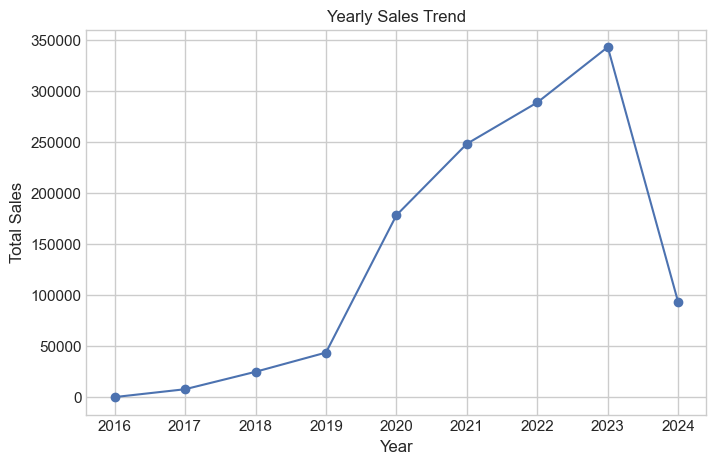

In [195]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert OrderDate to datetime if not already
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

# Extract year
df['Year'] = df['OrderDate'].dt.year

# Aggregate total sales by year
yearly_sales = df.groupby('Year')['WareHouseQuantity'].sum()

# Plot yearly sales
plt.figure(figsize=(8,5))
yearly_sales.plot(marker='o', linestyle='-')
plt.title('Yearly Sales Trend')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()


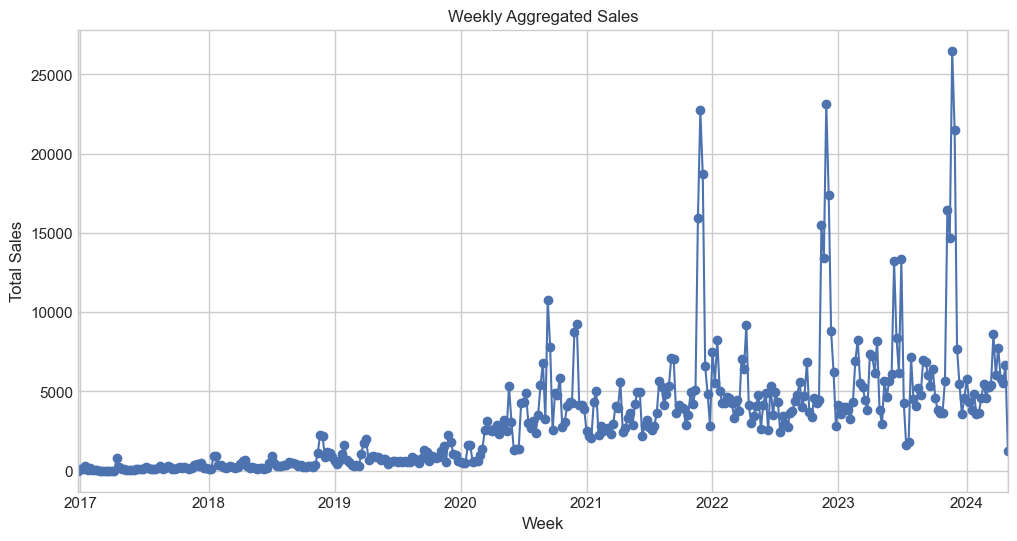

In [197]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert OrderDate to datetime if not already
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

# Set OrderDate as index (optional but useful)
df.set_index('OrderDate', inplace=True)

# Aggregate sales by week (sum of WareHouseQuantity per week)
weekly_sales = df['WareHouseQuantity'].resample('W').sum()

# Plot weekly aggregated sales
plt.figure(figsize=(12,6))
weekly_sales.plot(marker='o')
plt.title('Weekly Aggregated Sales')
plt.xlabel('Week')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()


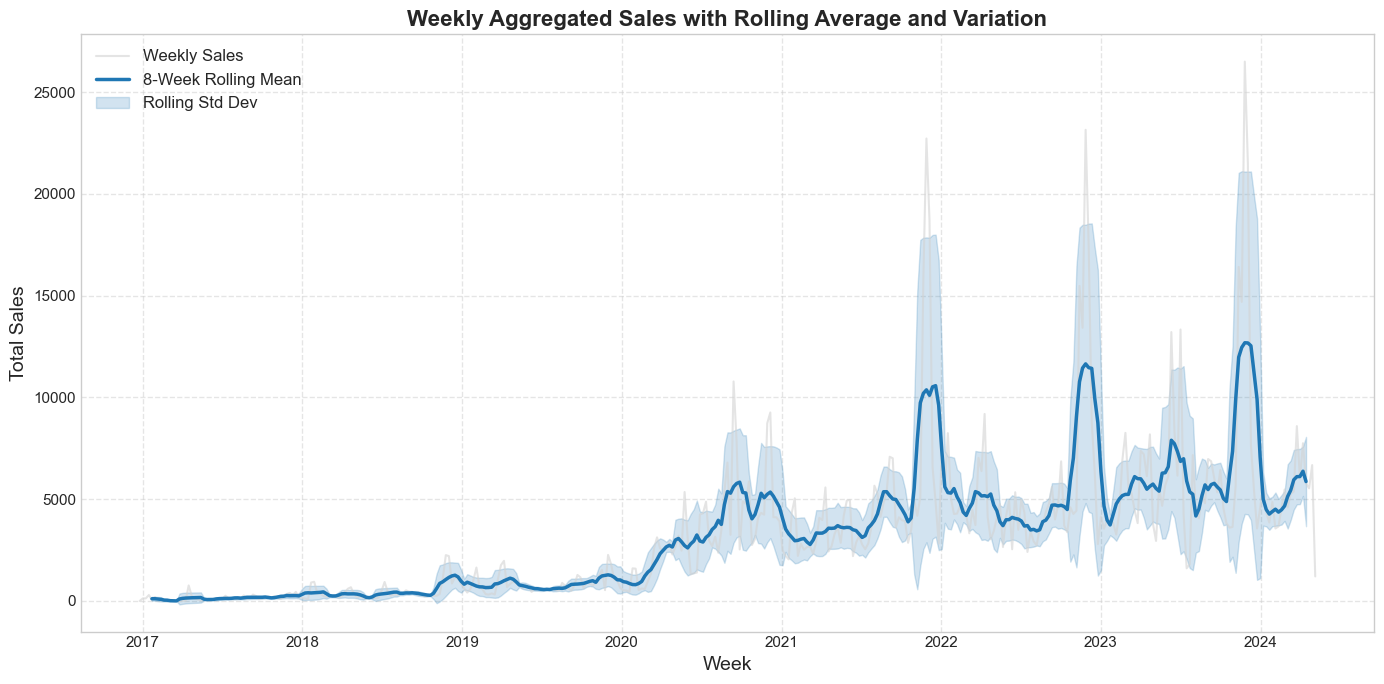

In [200]:
import matplotlib.pyplot as plt

# If 'OrderDate' is already the index and is datetime:
weekly_sales = df['WareHouseQuantity'].resample('W').sum()

rolling_mean = weekly_sales.rolling(window=8, center=True).mean()
rolling_std = weekly_sales.rolling(window=8, center=True).std()

plt.figure(figsize=(14,7))
plt.plot(weekly_sales.index, weekly_sales, color='lightgray', label='Weekly Sales', alpha=0.6)
plt.plot(rolling_mean.index, rolling_mean, color='#1f77b4', linewidth=2.5, label='8-Week Rolling Mean')
plt.fill_between(rolling_mean.index, 
                 rolling_mean - rolling_std, 
                 rolling_mean + rolling_std, 
                 color='#1f77b4', alpha=0.2, label='Rolling Std Dev')

plt.title('Weekly Aggregated Sales with Rolling Average and Variation', fontsize=16, weight='bold')
plt.xlabel('Week', fontsize=14)
plt.ylabel('Total Sales', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


### What is Seasonality?

Seasonality refers to patterns in data that repeat at regular intervals over time. These predictable fluctuations occur periodically—daily, weekly, monthly, or yearly.

For example:

Retail sales often spike every December due to holiday shopping (annual seasonality).

Ice cream sales tend to rise in the summer months (seasonal pattern).

Website traffic may be higher on weekdays than weekends (weekly seasonality).

In our dataset, we observe yearly seasonality as well. The line plot clearly shows repeating sales patterns around November in 2021, 2022, and 2023, indicating consistent annual peaks.

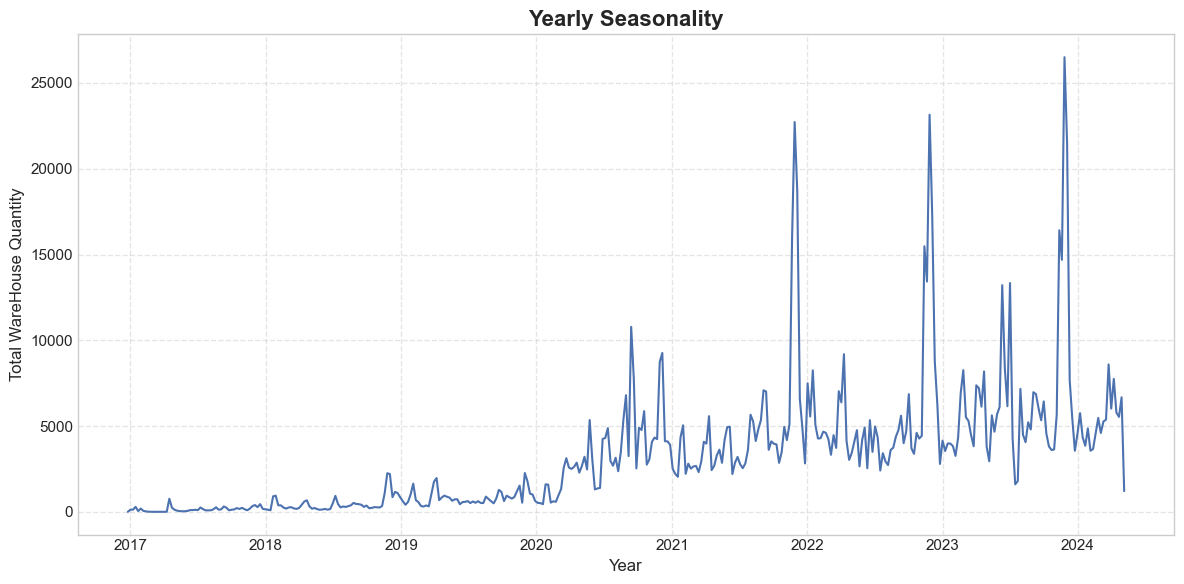

In [204]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare DataFrame for seaborn (reset index)
weekly_sales_df = weekly_sales.reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=weekly_sales_df, x='OrderDate', y='WareHouseQuantity')

plt.title('Yearly Seasonality', fontsize=16, weight='bold')
plt.xlabel('Year')
plt.ylabel('Total WareHouse Quantity')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
